In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from keras.datasets import mnist
from keras.layers import Dense, LSTM
from keras.utils import to_categorical
from keras.models import Sequential
import h5py
from keras.models import load_model
import warnings
warnings.filterwarnings('ignore')
import os.path
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.externals import joblib
from sklearn.metrics import accuracy_score

In [2]:
Path = './data/实际油藏数据1.xls'

df0 = pd.read_excel(Path,header=0,sheet_name = 0) #产液
df1 = pd.read_excel(Path,header=0,sheet_name = 1) #产油
df2 = pd.read_excel(Path,header=0,sheet_name = 2) #注水
df3 = pd.read_excel(Path,header=0,sheet_name = 3) #位置

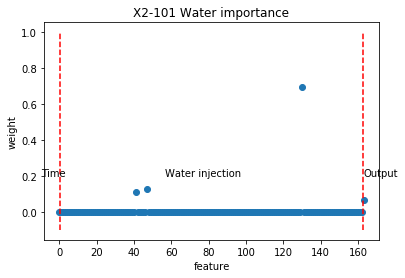

X2-101 Water model.score= -4119.692325413442
X2-101 Water : train_mae= 0.000974 ; train_mse= 0.000001 ; test_mae= 5.496537 ; test_mse= 36.892662


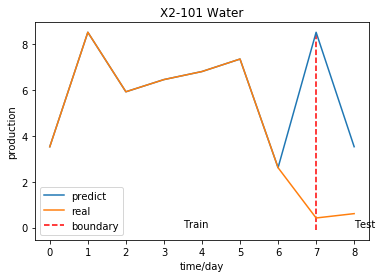

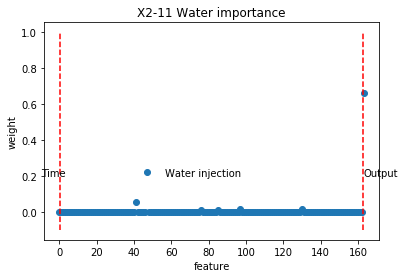

X2-11 Water model.score= 0.11774806841751362
X2-11 Water : train_mae= 0.147294 ; train_mse= 0.451849 ; test_mae= 3.945025 ; test_mse= 47.431101


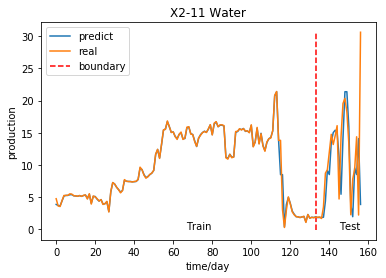

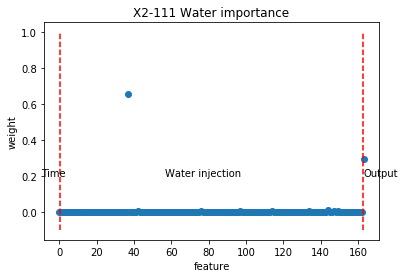

X2-111 Water model.score= -0.9203420712656287
X2-111 Water : train_mae= 0.602665 ; train_mse= 1.840733 ; test_mae= 1.007491 ; test_mse= 8.571345


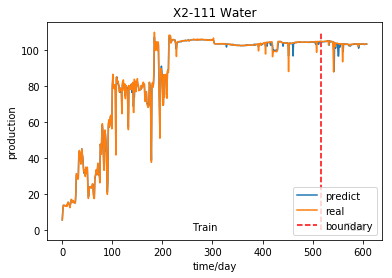

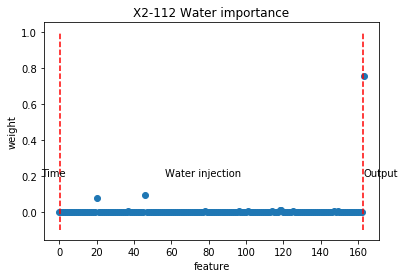

X2-112 Water model.score= 0.4546687951464878
X2-112 Water : train_mae= 0.167735 ; train_mse= 0.838586 ; test_mae= 1.704852 ; test_mse= 4.127599


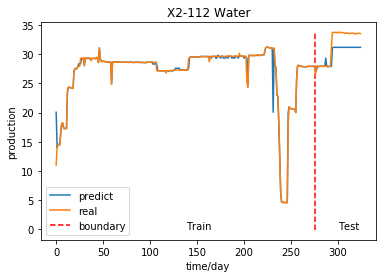

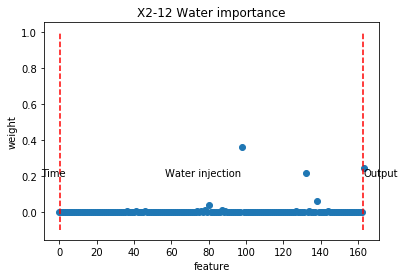

X2-12 Water model.score= 0.3987088006165459
X2-12 Water : train_mae= 0.753559 ; train_mse= 3.897676 ; test_mae= 7.480114 ; test_mse= 114.621615


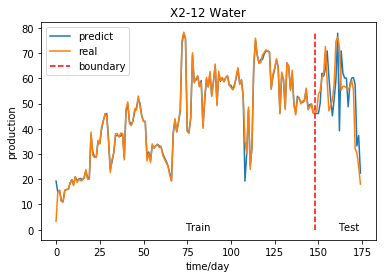

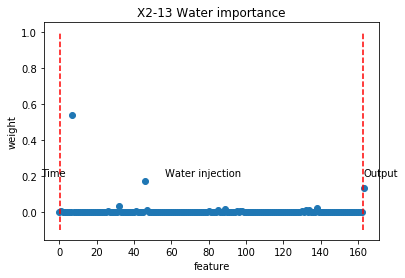

X2-13 Water model.score= -1.7212314037458993
X2-13 Water : train_mae= 0.831940 ; train_mse= 25.294506 ; test_mae= 8.623398 ; test_mse= 159.794448


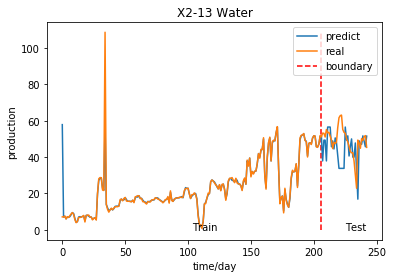

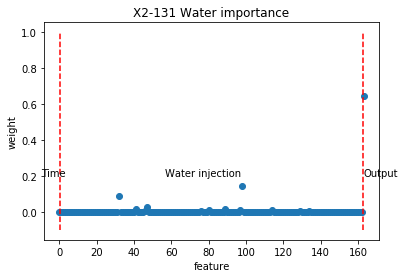

X2-131 Water model.score= -0.48888267870746094
X2-131 Water : train_mae= 0.380467 ; train_mse= 1.092070 ; test_mae= 0.070434 ; test_mse= 0.016775


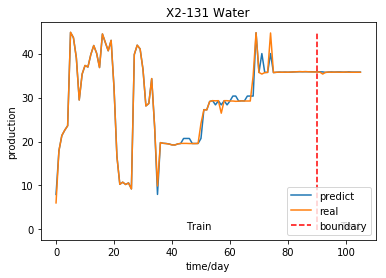

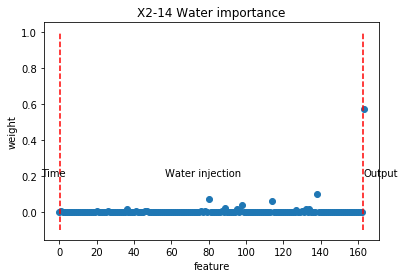

X2-14 Water model.score= -3.036783153288521
X2-14 Water : train_mae= 0.058249 ; train_mse= 0.005543 ; test_mae= 6.037554 ; test_mse= 58.556310


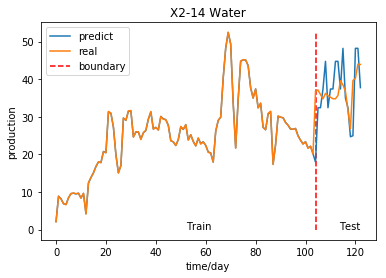

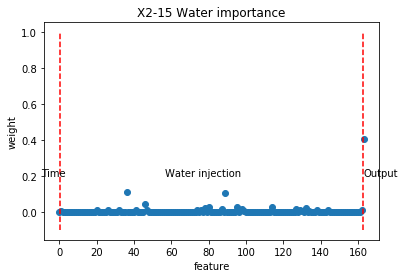

X2-15 Water model.score= 0.14260287085836476
X2-15 Water : train_mae= 0.833896 ; train_mse= 1.371062 ; test_mae= 8.001957 ; test_mse= 109.789069


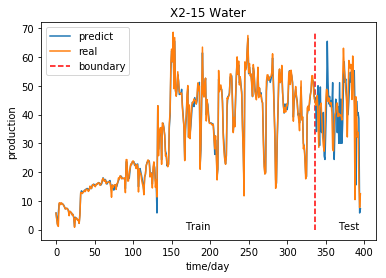

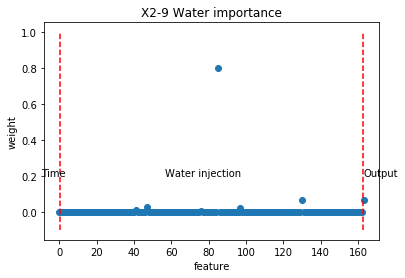

X2-9 Water model.score= -1.8308073351564795
X2-9 Water : train_mae= 0.142978 ; train_mse= 0.167581 ; test_mae= 3.102820 ; test_mse= 13.845191


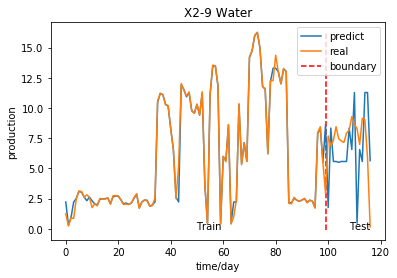

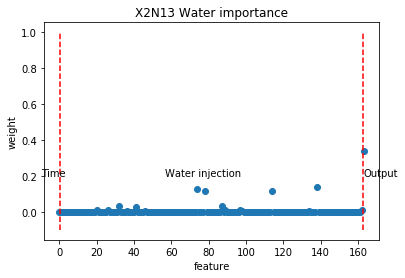

X2N13 Water model.score= 0.3673984038983211
X2N13 Water : train_mae= 0.189315 ; train_mse= 0.716181 ; test_mae= 7.885243 ; test_mse= 71.667924


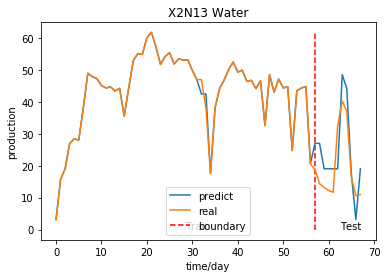

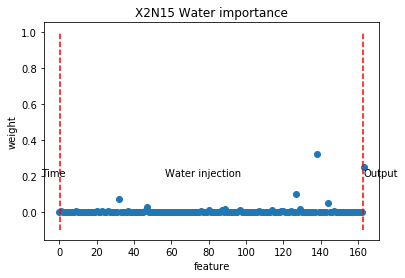

X2N15 Water model.score= 0.4603661134573953
X2N15 Water : train_mae= 0.401140 ; train_mse= 1.574514 ; test_mae= 4.322353 ; test_mse= 35.593420


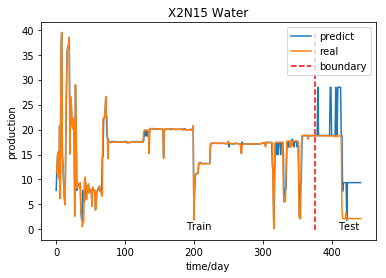

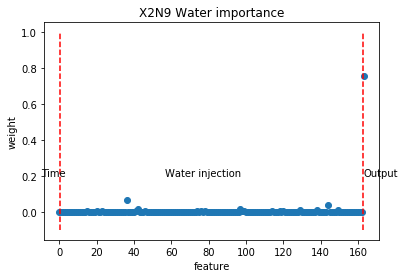

X2N9 Water model.score= 0.547924317184306
X2N9 Water : train_mae= 0.058065 ; train_mse= 0.008309 ; test_mae= 0.147202 ; test_mse= 0.077212


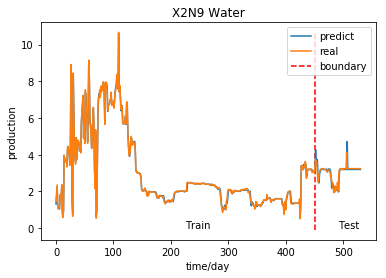

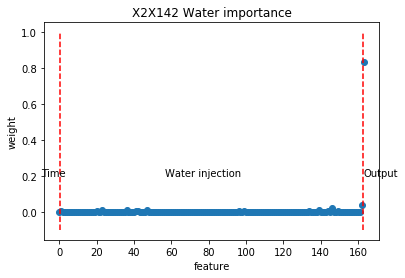

X2X142 Water model.score= 0.4537005715997703
X2X142 Water : train_mae= 0.228710 ; train_mse= 0.486077 ; test_mae= 2.319695 ; test_mse= 26.036222


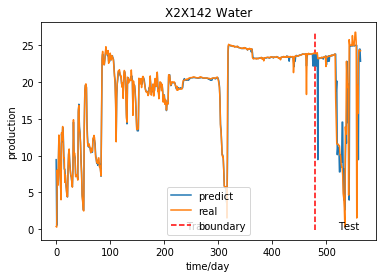

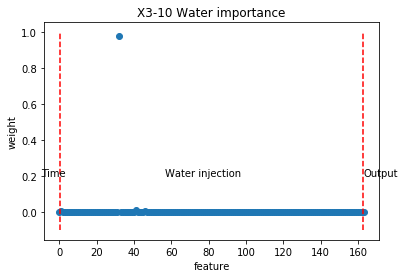

X3-10 Water model.score= -0.43174145302864275
X3-10 Water : train_mae= 0.001233 ; train_mse= 0.000002 ; test_mae= 19.560473 ; test_mse= 392.339968


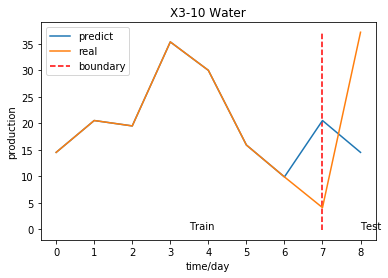

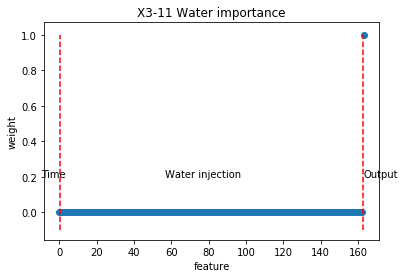

X3-11 Water model.score= -8.955156735454931
X3-11 Water : train_mae= 0.001676 ; train_mse= 0.000003 ; test_mae= 1.322120 ; test_mse= 2.201815


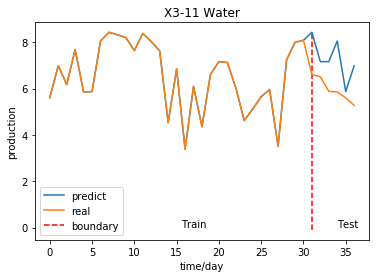

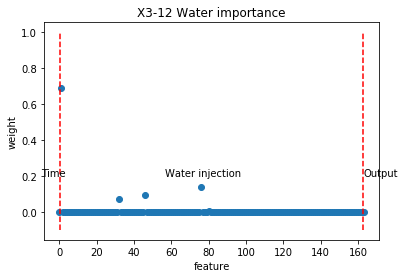

X3-12 Water model.score= -29.274265907917215
X3-12 Water : train_mae= 0.001034 ; train_mse= 0.000001 ; test_mae= 4.407753 ; test_mse= 20.091947


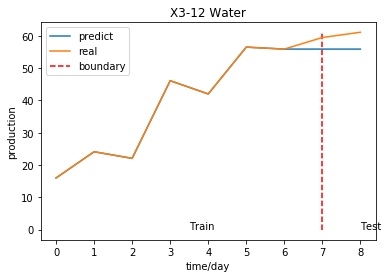

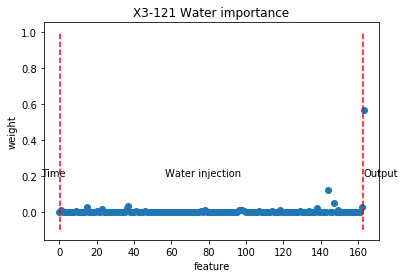

X3-121 Water model.score= 0.51560956214957
X3-121 Water : train_mae= 0.294046 ; train_mse= 0.323071 ; test_mae= 2.955736 ; test_mse= 25.543364


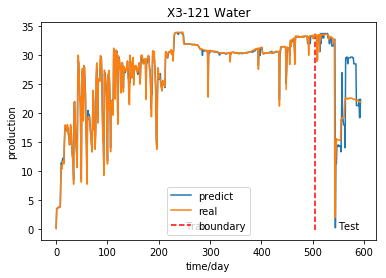

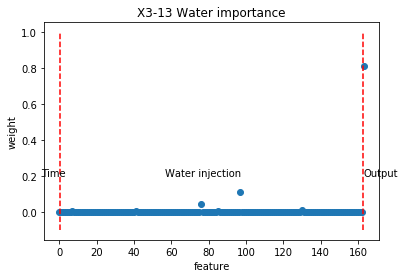

X3-13 Water model.score= -1.8466213886919163
X3-13 Water : train_mae= 0.128518 ; train_mse= 0.129807 ; test_mae= 19.456379 ; test_mse= 528.253371


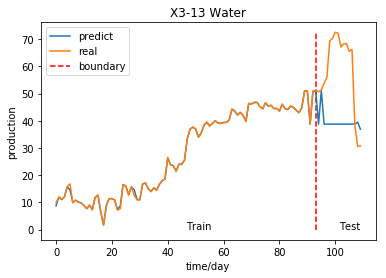

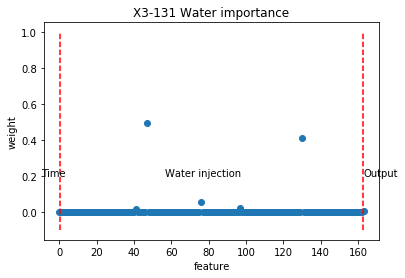

X3-131 Water model.score= -73.71843966536743
X3-131 Water : train_mae= 0.001275 ; train_mse= 0.000002 ; test_mae= 1.266319 ; test_mse= 1.625316


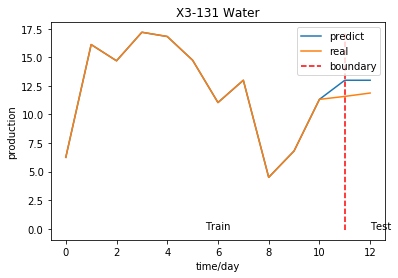

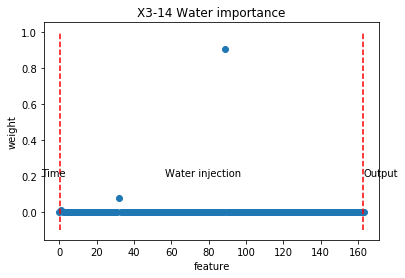

X3-14 Water model.score= -76.63169339006507
X3-14 Water : train_mae= 0.001149 ; train_mse= 0.000002 ; test_mae= 21.129268 ; test_mse= 446.453265


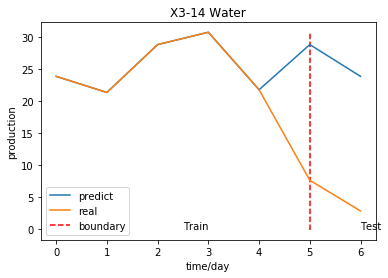

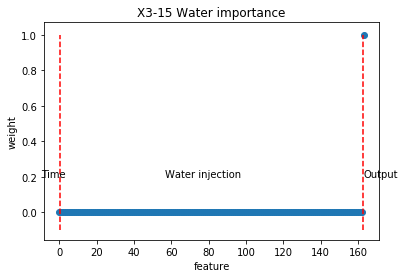

X3-15 Water model.score= 0.6690774711822082
X3-15 Water : train_mae= 0.001430 ; train_mse= 0.000003 ; test_mae= 0.502257 ; test_mse= 0.441308


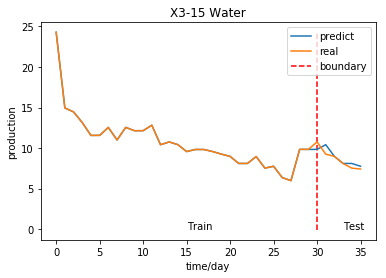

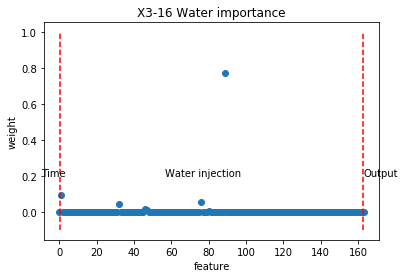

X3-16 Water model.score= -0.9670591289360702
X3-16 Water : train_mae= 0.001023 ; train_mse= 0.000001 ; test_mae= 43.819095 ; test_mse= 4558.941245


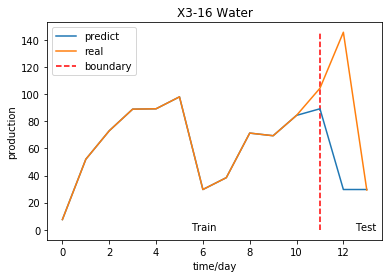

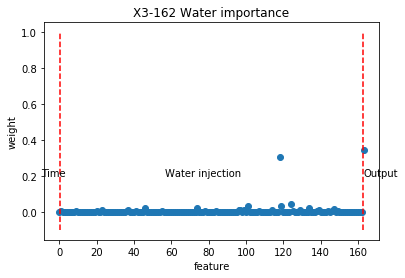

X3-162 Water model.score= 0.6565762053227544
X3-162 Water : train_mae= 0.379295 ; train_mse= 0.973484 ; test_mae= 0.387641 ; test_mse= 0.242370


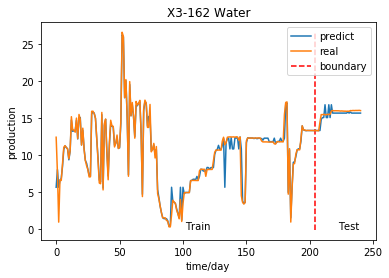

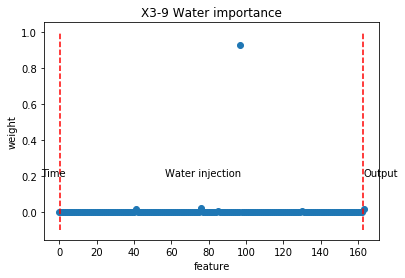

X3-9 Water model.score= -1.0043279566027854
X3-9 Water : train_mae= 0.035307 ; train_mse= 0.014940 ; test_mae= 2.994140 ; test_mse= 14.059499


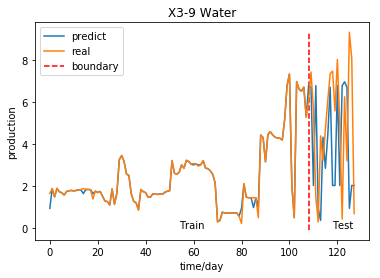

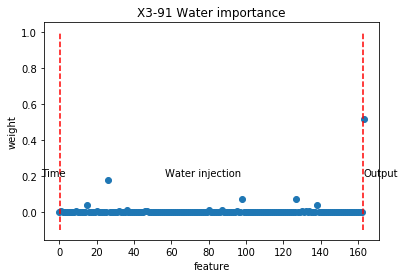

X3-91 Water model.score= -214.8190189077495
X3-91 Water : train_mae= 0.308144 ; train_mse= 0.755239 ; test_mae= 8.302200 ; test_mse= 111.629041


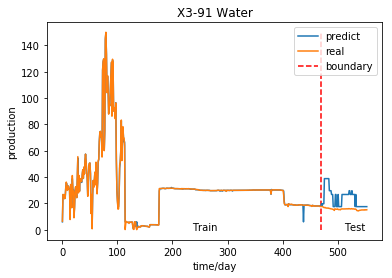

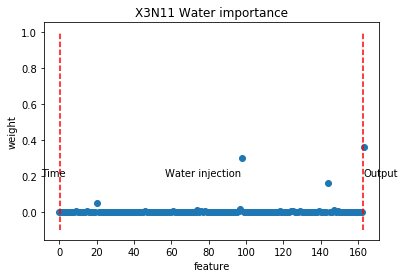

X3N11 Water model.score= 0.2249818134403434
X3N11 Water : train_mae= 0.022496 ; train_mse= 0.001198 ; test_mae= 0.029945 ; test_mse= 0.001322


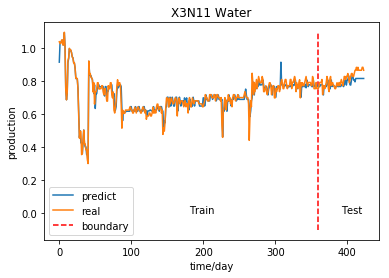

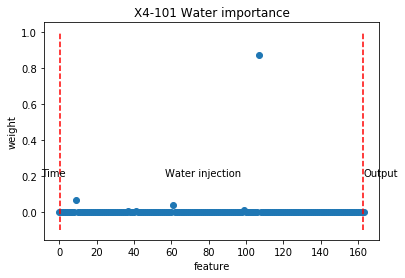

X4-101 Water model.score= -0.8202005288495395
X4-101 Water : train_mae= 0.317352 ; train_mse= 0.957628 ; test_mae= 1.820120 ; test_mse= 5.916159


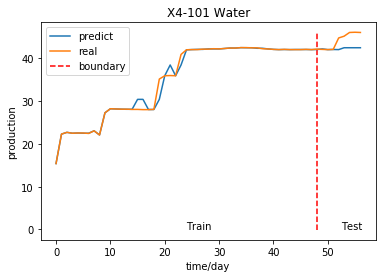

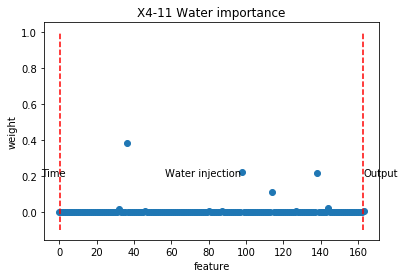

X4-11 Water model.score= 0.30611900970304984
X4-11 Water : train_mae= 0.454283 ; train_mse= 0.578395 ; test_mae= 6.750477 ; test_mse= 80.990281


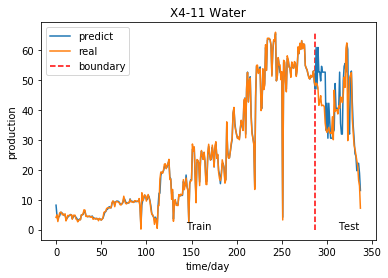

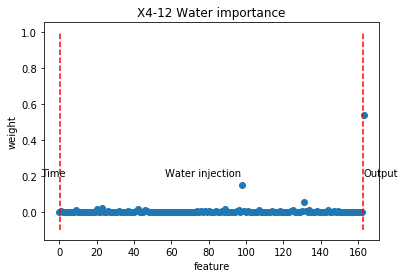

X4-12 Water model.score= -2.035816851282986
X4-12 Water : train_mae= 0.865935 ; train_mse= 6.183443 ; test_mae= 0.775275 ; test_mse= 3.439339


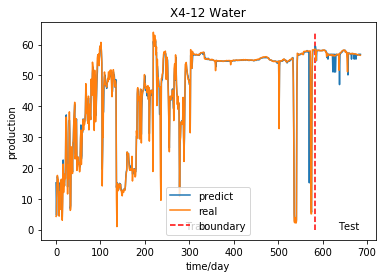

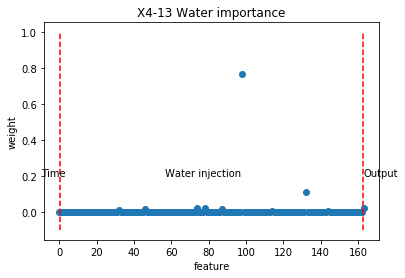

X4-13 Water model.score= 0.49767232409505924
X4-13 Water : train_mae= 0.484772 ; train_mse= 0.502177 ; test_mae= 9.691474 ; test_mse= 161.467558


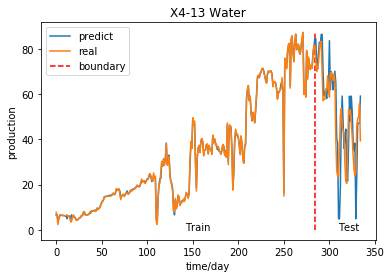

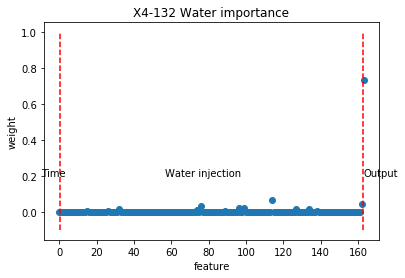

X4-132 Water model.score= -6.6288617613009135
X4-132 Water : train_mae= 0.169234 ; train_mse= 0.257588 ; test_mae= 0.110203 ; test_mse= 0.013977


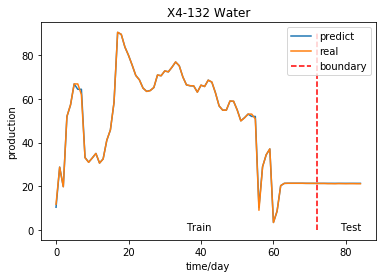

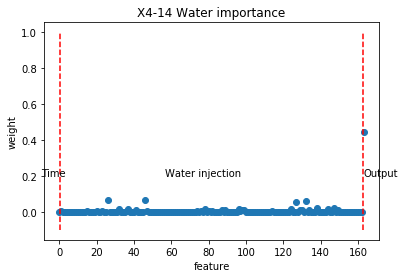

X4-14 Water model.score= -2.154386179338415
X4-14 Water : train_mae= 0.166467 ; train_mse= 0.085518 ; test_mae= 0.466447 ; test_mse= 1.052568


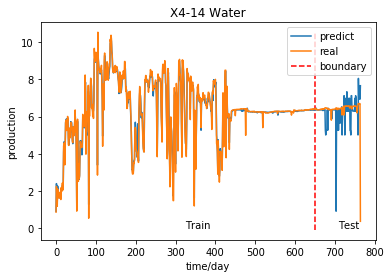

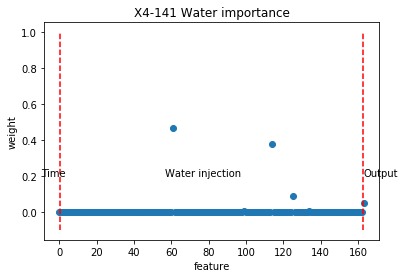

X4-141 Water model.score= -0.20420380312657405
X4-141 Water : train_mae= 0.080924 ; train_mse= 0.138937 ; test_mae= 0.293483 ; test_mse= 0.222013


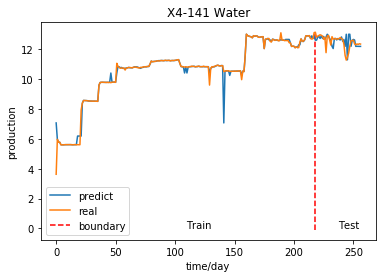

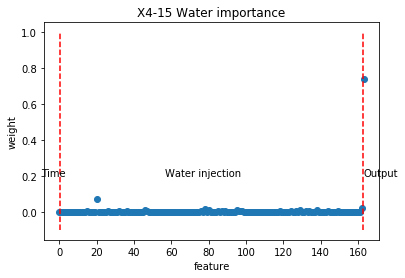

X4-15 Water model.score= -0.0774431511588034
X4-15 Water : train_mae= 0.630519 ; train_mse= 1.110788 ; test_mae= 0.793099 ; test_mse= 14.186831


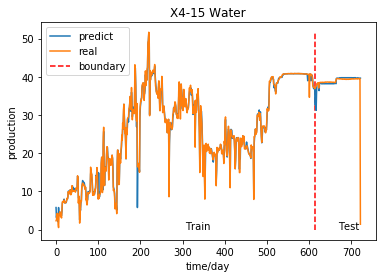

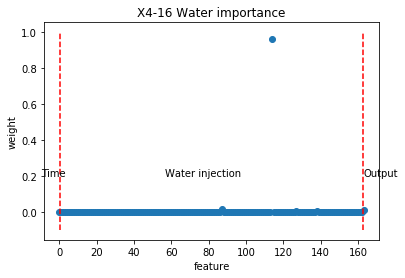

X4-16 Water model.score= 0.2122668898720963
X4-16 Water : train_mae= 1.094345 ; train_mse= 2.143733 ; test_mae= 22.501766 ; test_mse= 916.404525


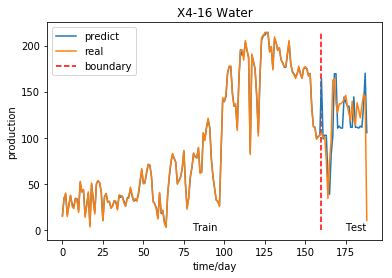

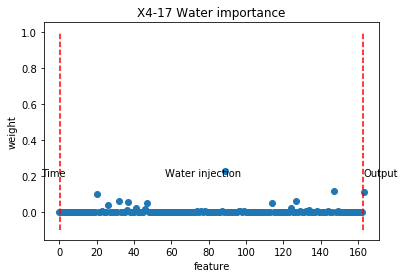

X4-17 Water model.score= -2.509623342734733
X4-17 Water : train_mae= 0.629725 ; train_mse= 6.119836 ; test_mae= 5.453265 ; test_mse= 81.597923


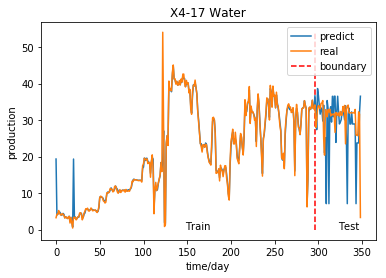

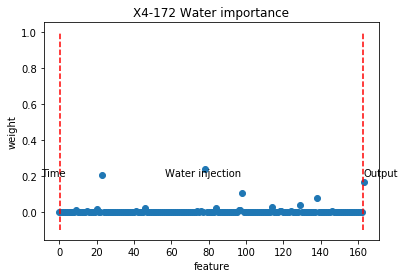

X4-172 Water model.score= -3.800930192416924
X4-172 Water : train_mae= 0.369654 ; train_mse= 2.861073 ; test_mae= 2.620629 ; test_mse= 59.963349


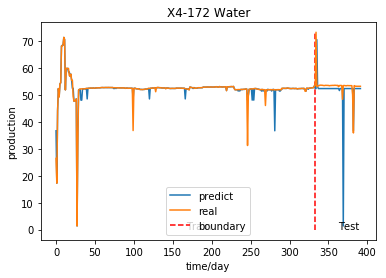

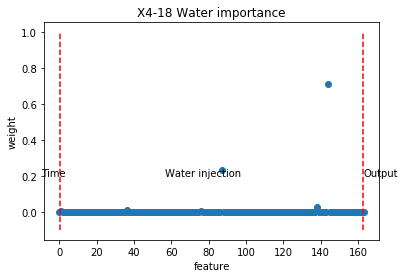

X4-18 Water model.score= 0.3929348350243257
X4-18 Water : train_mae= 0.001103 ; train_mse= 0.000002 ; test_mae= 4.805389 ; test_mse= 35.390407


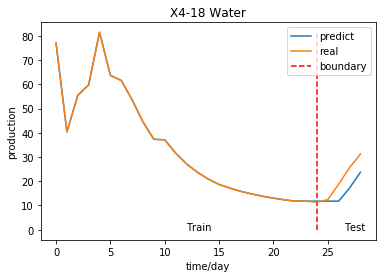

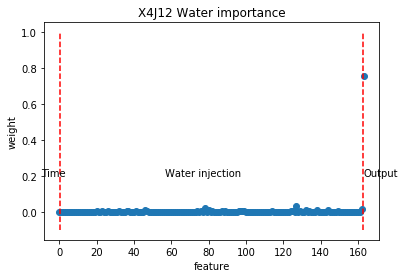

X4J12 Water model.score= -0.9081447198014541
X4J12 Water : train_mae= 1.311850 ; train_mse= 5.196345 ; test_mae= 2.396587 ; test_mse= 119.881722


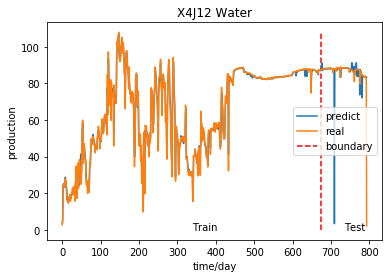

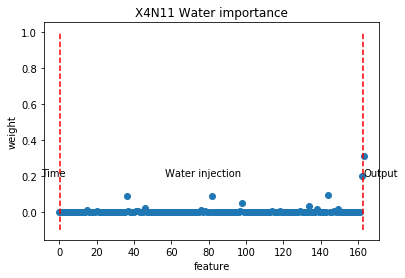

X4N11 Water model.score= -0.2638013750027366
X4N11 Water : train_mae= 0.212368 ; train_mse= 0.175851 ; test_mae= 0.447602 ; test_mse= 2.239912


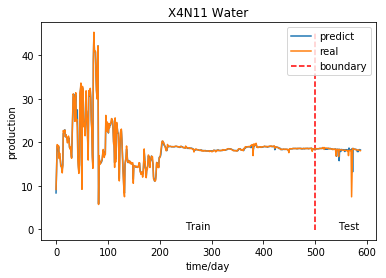

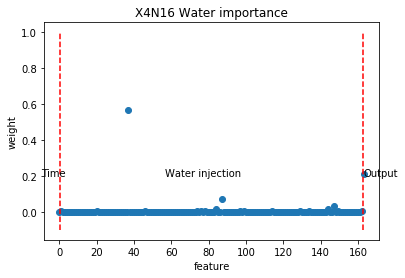

X4N16 Water model.score= -0.8454814640492482
X4N16 Water : train_mae= 0.567125 ; train_mse= 0.639577 ; test_mae= 1.198222 ; test_mse= 12.915327


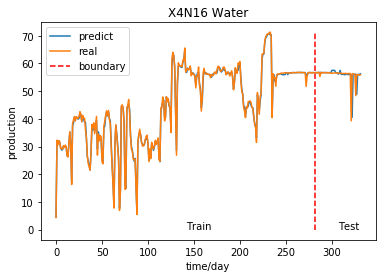

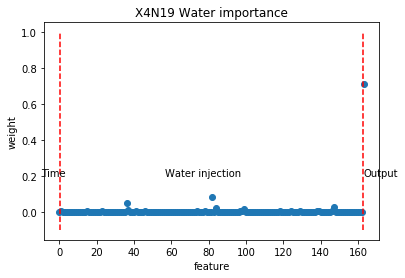

X4N19 Water model.score= 0.6036662629911027
X4N19 Water : train_mae= 0.286059 ; train_mse= 1.295706 ; test_mae= 1.858254 ; test_mse= 4.856053


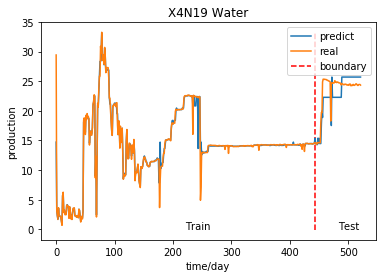

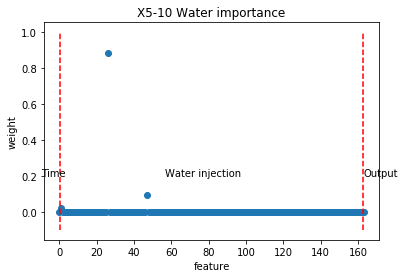

X5-10 Water model.score= 0.0
X5-10 Water : train_mae= 4.086116 ; train_mse= 41.724078 ; test_mae= 10.061597 ; test_mse= 101.235728


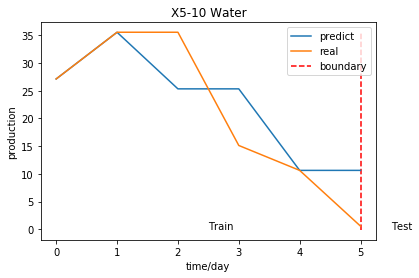

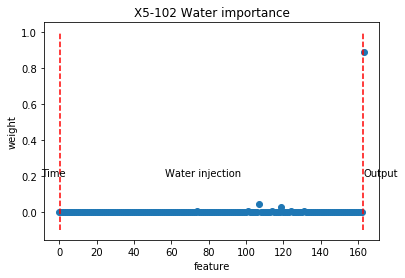

X5-102 Water model.score= 0.4682024027114211
X5-102 Water : train_mae= 0.202293 ; train_mse= 0.636632 ; test_mae= 0.287854 ; test_mse= 0.282217


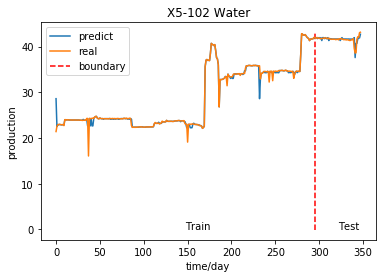

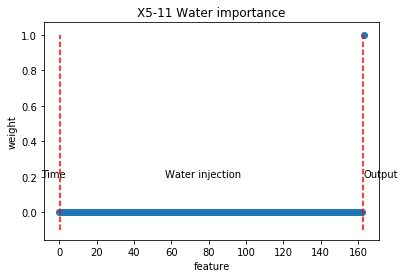

X5-11 Water model.score= -14.465200883703101
X5-11 Water : train_mae= 0.007871 ; train_mse= 0.000701 ; test_mae= 1.712586 ; test_mse= 3.272705


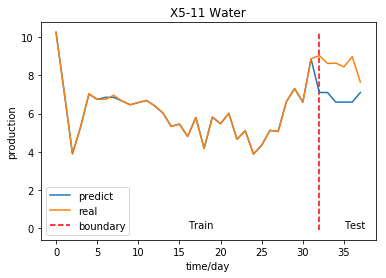

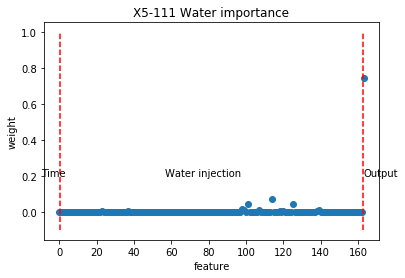

X5-111 Water model.score= 0.8130803008760732
X5-111 Water : train_mae= 0.446355 ; train_mse= 2.289130 ; test_mae= 3.866586 ; test_mse= 90.842363


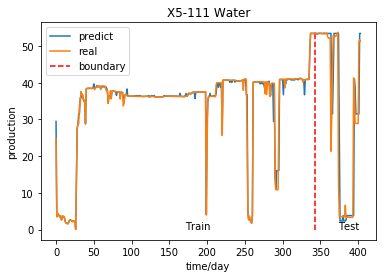

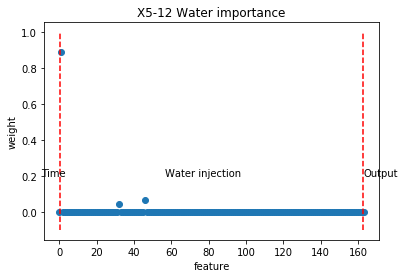

X5-12 Water model.score= -0.8909167539427073
X5-12 Water : train_mae= 0.000884 ; train_mse= 0.000001 ; test_mae= 22.924162 ; test_mse= 847.390053


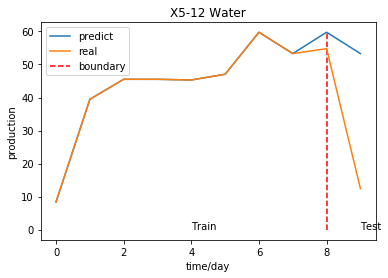

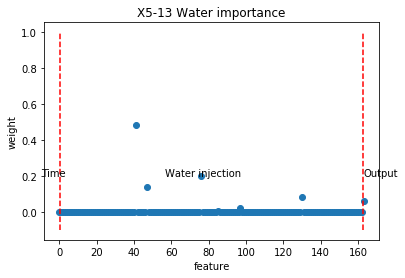

X5-13 Water model.score= 0.47618971666964427
X5-13 Water : train_mae= 0.349352 ; train_mse= 1.397893 ; test_mae= 20.785305 ; test_mse= 650.455521


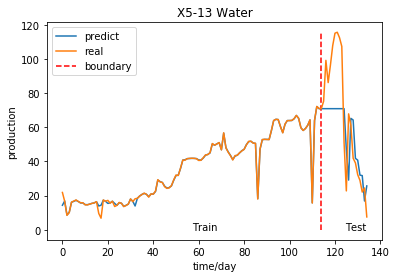

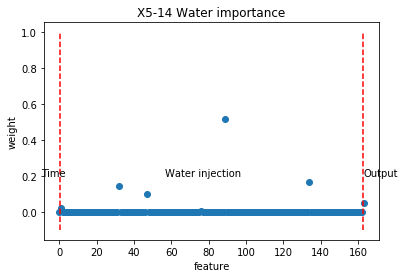

X5-14 Water model.score= -0.25807909729185874
X5-14 Water : train_mae= 0.000834 ; train_mse= 0.000001 ; test_mae= 16.314181 ; test_mse= 273.407511


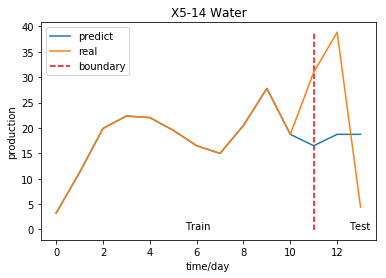

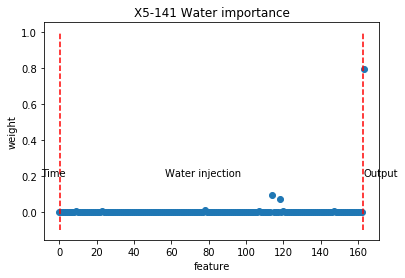

X5-141 Water model.score= -6.399925160695433
X5-141 Water : train_mae= 0.260932 ; train_mse= 0.870415 ; test_mae= 15.764603 ; test_mse= 360.217092


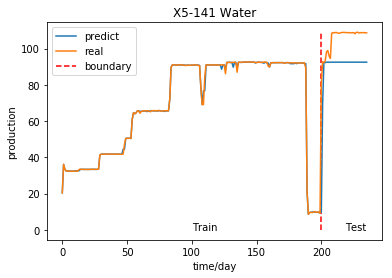

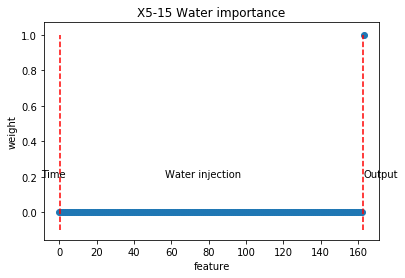

X5-15 Water model.score= -0.16026634878919999
X5-15 Water : train_mae= 0.008908 ; train_mse= 0.000930 ; test_mae= 0.383025 ; test_mse= 0.280128


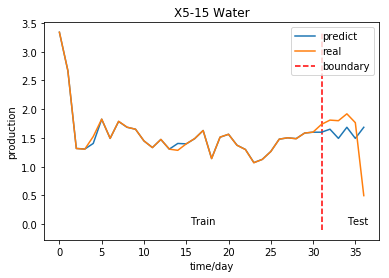

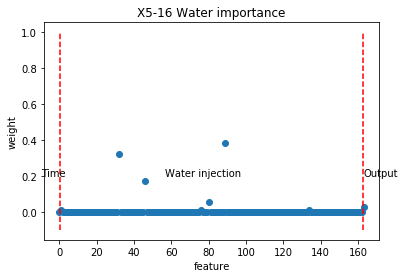

X5-16 Water model.score= -0.5271529496555708
X5-16 Water : train_mae= 0.001031 ; train_mse= 0.000001 ; test_mae= 22.192748 ; test_mse= 752.150400


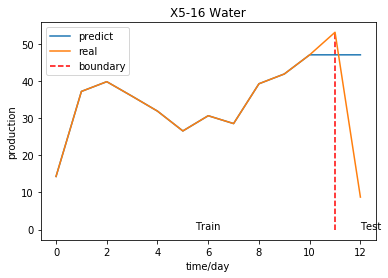

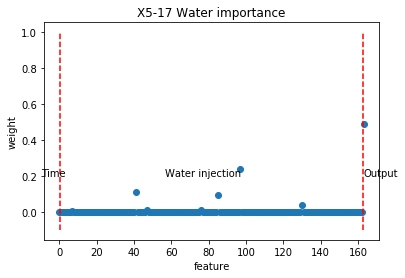

X5-17 Water model.score= 0.12055109296862099
X5-17 Water : train_mae= 0.017314 ; train_mse= 0.001282 ; test_mae= 0.860218 ; test_mse= 1.309190


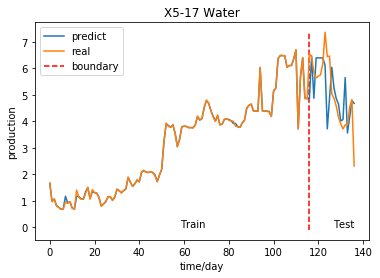

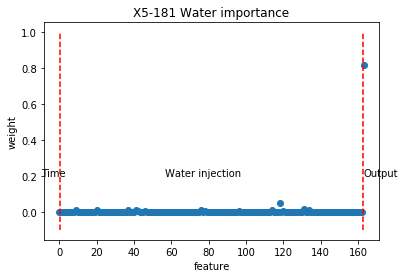

X5-181 Water model.score= -0.2829101579064426
X5-181 Water : train_mae= 1.394545 ; train_mse= 23.867693 ; test_mae= 1.469459 ; test_mse= 3.512053


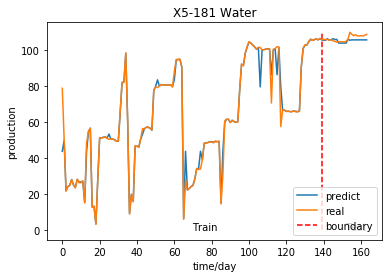

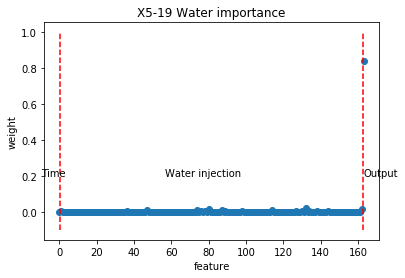

X5-19 Water model.score= -0.39221957192115053
X5-19 Water : train_mae= 0.058849 ; train_mse= 0.032220 ; test_mae= 0.748267 ; test_mse= 1.168683


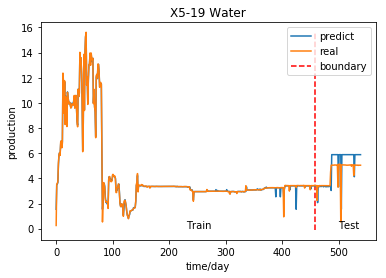

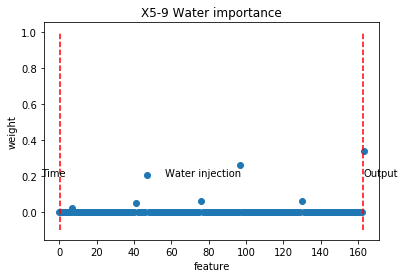

X5-9 Water model.score= -2.013213211486257
X5-9 Water : train_mae= 0.067638 ; train_mse= 0.043346 ; test_mae= 1.026136 ; test_mse= 2.156866


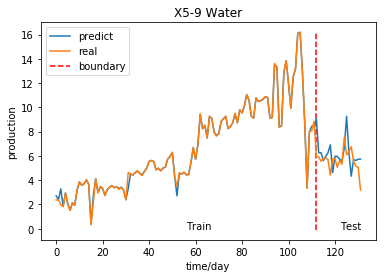

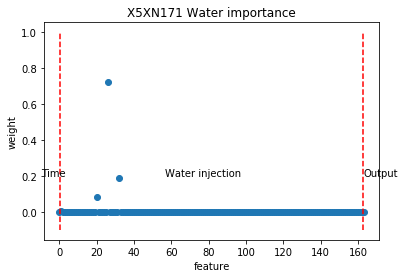

X5XN171 Water model.score= 0.0
X5XN171 Water : train_mae= 0.000451 ; train_mse= 0.000000 ; test_mae= 0.072072 ; test_mse= 0.005194


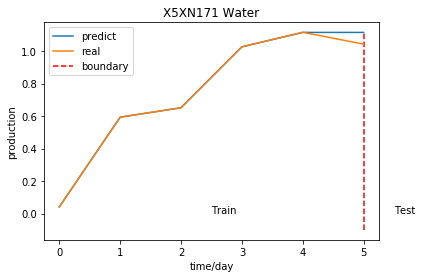

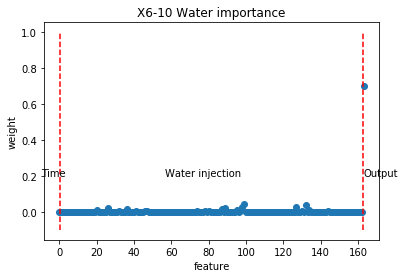

X6-10 Water model.score= 0.1772983644120829
X6-10 Water : train_mae= 0.753783 ; train_mse= 3.716101 ; test_mae= 4.941004 ; test_mse= 65.836730


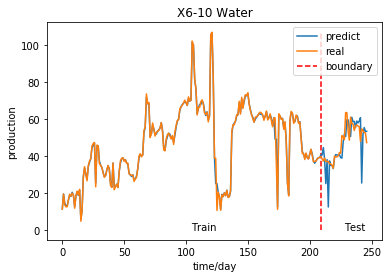

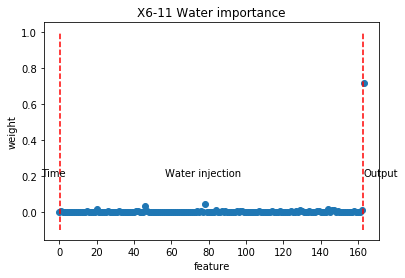

X6-11 Water model.score= -1.040057991120118
X6-11 Water : train_mae= 1.939963 ; train_mse= 10.351762 ; test_mae= 8.239257 ; test_mse= 229.049979


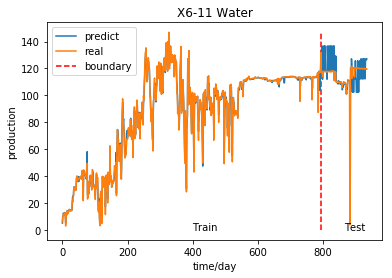

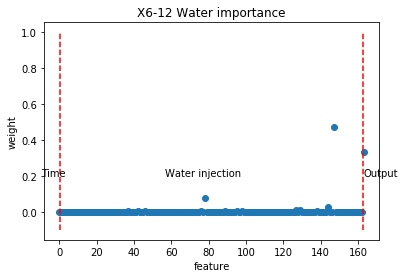

X6-12 Water model.score= 0.7432594275865503
X6-12 Water : train_mae= 1.015970 ; train_mse= 3.008010 ; test_mae= 5.278115 ; test_mse= 188.508145


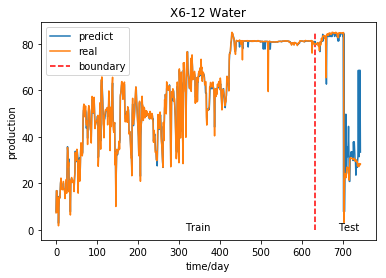

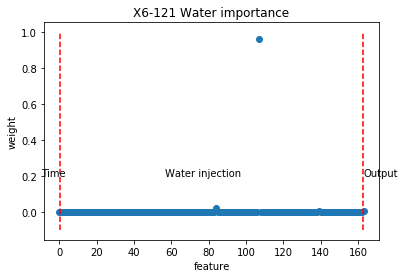

X6-121 Water model.score= 0.06461600694708525
X6-121 Water : train_mae= 0.091654 ; train_mse= 0.053803 ; test_mae= 0.290935 ; test_mse= 0.175020


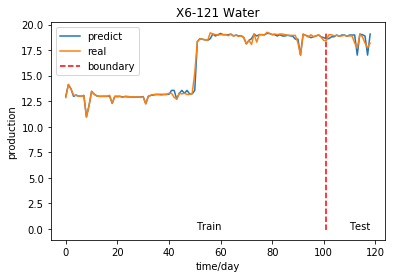

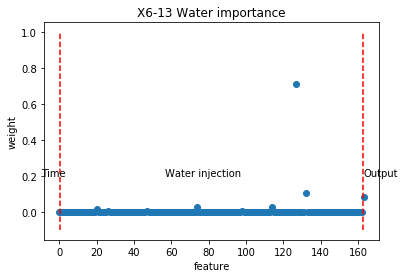

X6-13 Water model.score= 0.06619905681522154
X6-13 Water : train_mae= 1.029641 ; train_mse= 2.122563 ; test_mae= 12.592045 ; test_mse= 409.061273


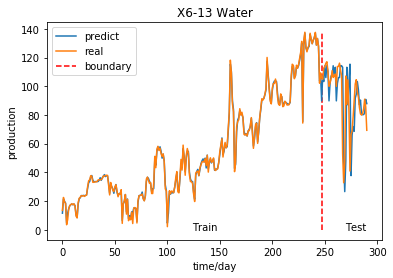

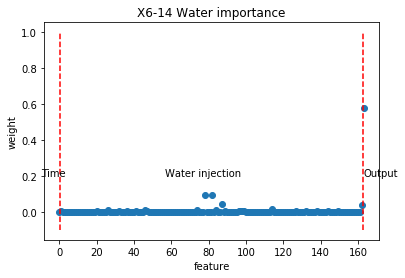

X6-14 Water model.score= 0.4225421178190566
X6-14 Water : train_mae= 0.172857 ; train_mse= 0.073095 ; test_mae= 0.511519 ; test_mse= 1.048250


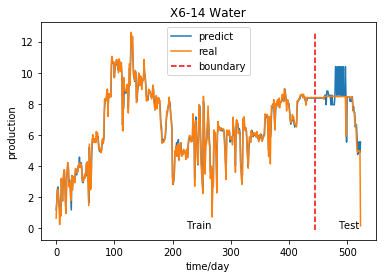

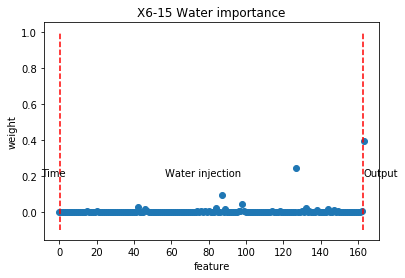

X6-15 Water model.score= -1.8193583855215394
X6-15 Water : train_mae= 0.838167 ; train_mse= 1.951445 ; test_mae= 1.533531 ; test_mse= 7.837336


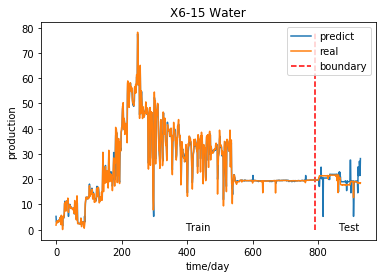

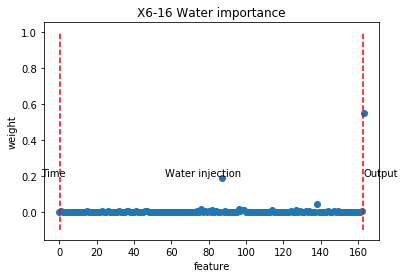

X6-16 Water model.score= -0.07092319592282181
X6-16 Water : train_mae= 0.609097 ; train_mse= 0.885244 ; test_mae= 3.550279 ; test_mse= 31.234024


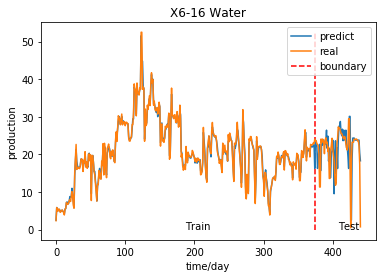

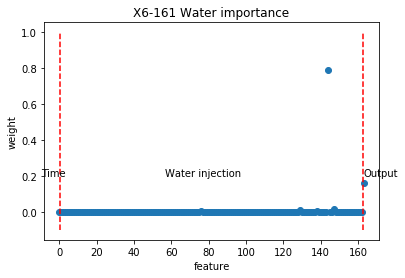

X6-161 Water model.score= -1.2344542604665025
X6-161 Water : train_mae= 0.159848 ; train_mse= 0.316664 ; test_mae= 0.765029 ; test_mse= 3.308234


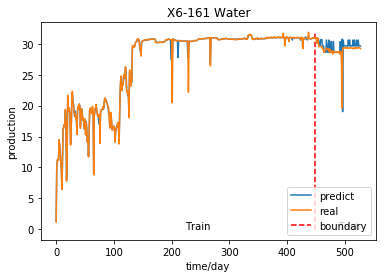

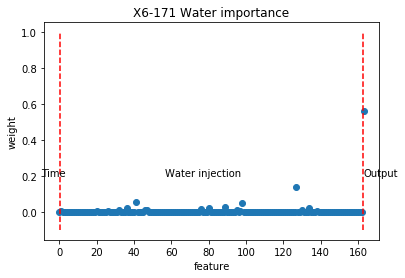

X6-171 Water model.score= -0.2031984629111394
X6-171 Water : train_mae= 0.105483 ; train_mse= 0.265984 ; test_mae= 4.622854 ; test_mse= 34.696596


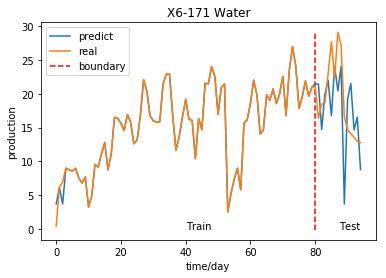

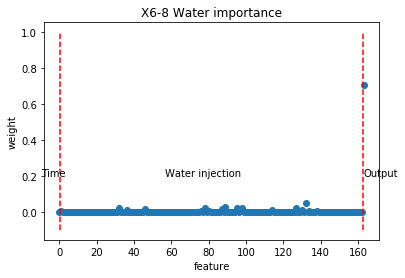

X6-8 Water model.score= 0.6496195705381016
X6-8 Water : train_mae= 0.010000 ; train_mse= 0.000277 ; test_mae= 0.484344 ; test_mse= 0.385932


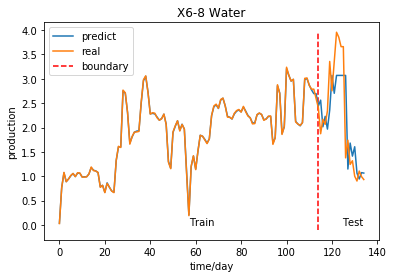

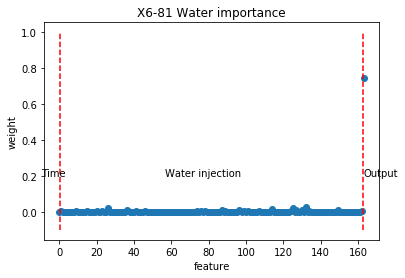

X6-81 Water model.score= 0.8385563219122065
X6-81 Water : train_mae= 0.128914 ; train_mse= 0.062571 ; test_mae= 0.934644 ; test_mse= 1.907363


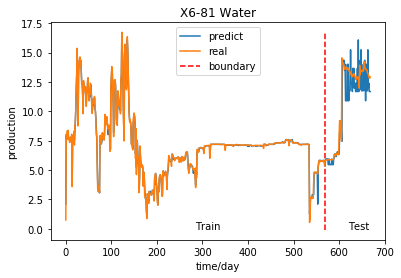

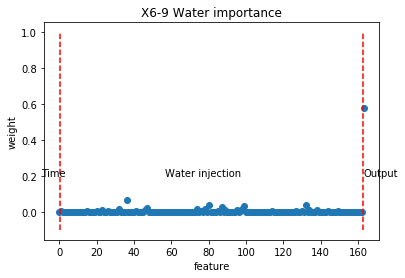

X6-9 Water model.score= -0.2455345930746129
X6-9 Water : train_mae= 0.638690 ; train_mse= 0.908475 ; test_mae= 5.533251 ; test_mse= 62.387767


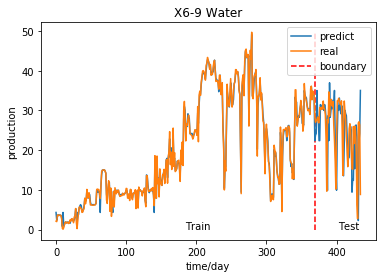

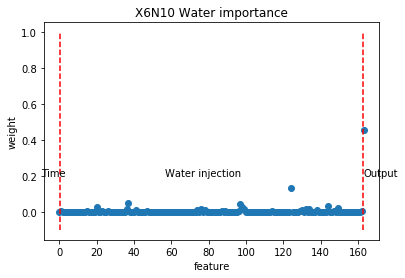

X6N10 Water model.score= 0.18902302606338628
X6N10 Water : train_mae= 1.029820 ; train_mse= 4.771514 ; test_mae= 8.103550 ; test_mse= 146.041474


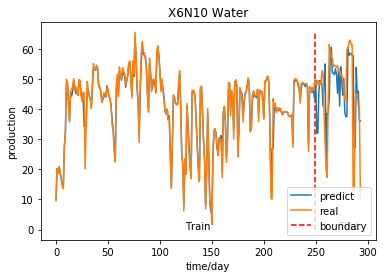

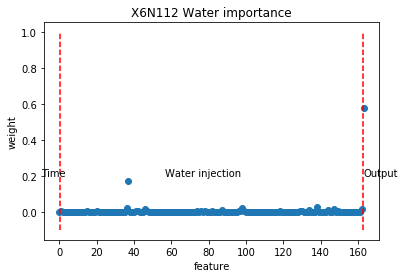

X6N112 Water model.score= -6.44968682070492
X6N112 Water : train_mae= 0.156102 ; train_mse= 0.183878 ; test_mae= 0.196125 ; test_mse= 0.197541


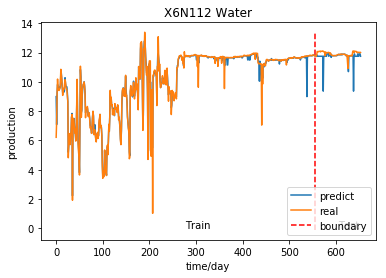

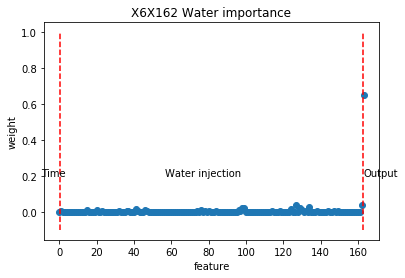

X6X162 Water model.score= -42.08879434666647
X6X162 Water : train_mae= 2.029695 ; train_mse= 10.582272 ; test_mae= 13.707841 ; test_mse= 223.049029


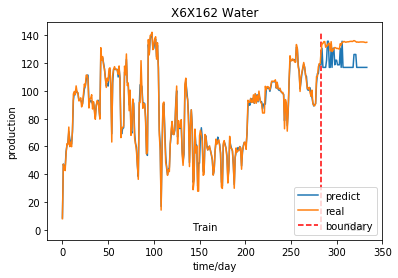

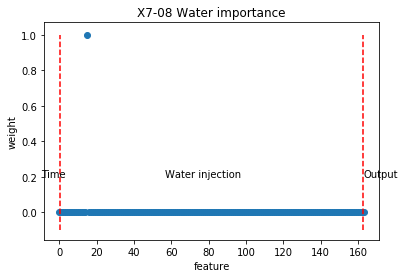

X7-08 Water model.score= 0.0
X7-08 Water : train_mae= 2.094559 ; train_mse= 6.578773 ; test_mae= 14.606566 ; test_mse= 213.351778


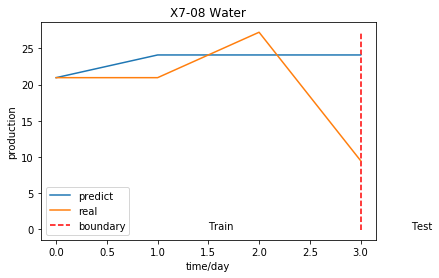

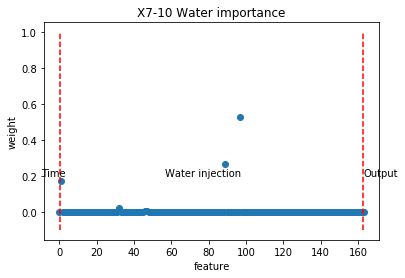

X7-10 Water model.score= -13.20646558752584
X7-10 Water : train_mae= 0.000897 ; train_mse= 0.000001 ; test_mae= 9.201573 ; test_mse= 91.080116


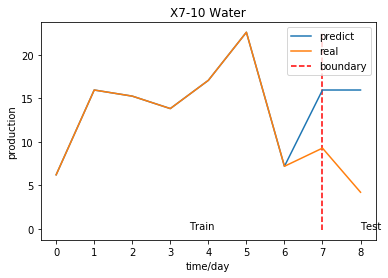

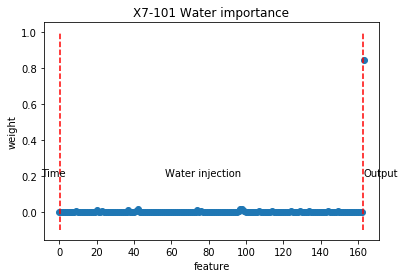

X7-101 Water model.score= -2.5274935000641716
X7-101 Water : train_mae= 0.082941 ; train_mse= 0.102187 ; test_mae= 0.280693 ; test_mse= 0.380136


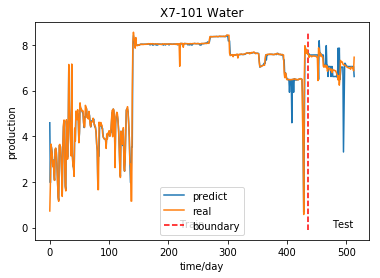

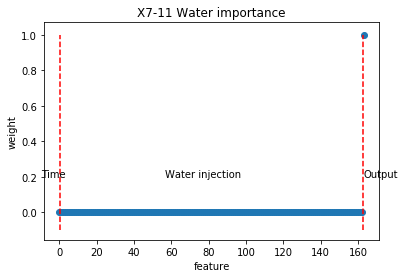

X7-11 Water model.score= -0.21005753123755658
X7-11 Water : train_mae= 0.255882 ; train_mse= 0.808691 ; test_mae= 2.943226 ; test_mse= 26.667751


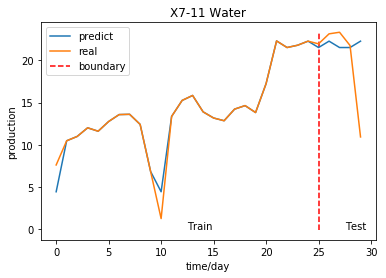

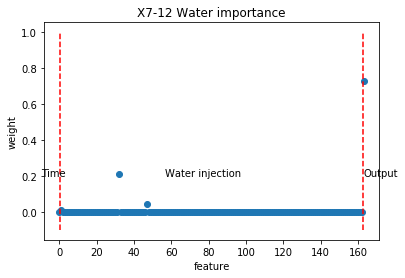

X7-12 Water model.score= -111.60597381649967
X7-12 Water : train_mae= 0.001005 ; train_mse= 0.000001 ; test_mae= 2.428702 ; test_mse= 5.997912


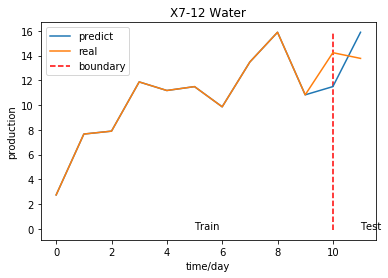

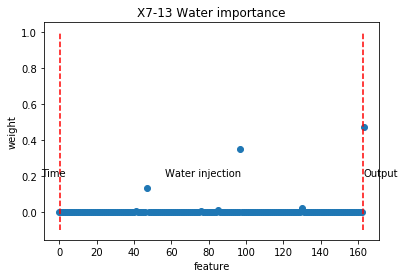

X7-13 Water model.score= 0.2837173184848528
X7-13 Water : train_mae= 0.117292 ; train_mse= 0.163507 ; test_mae= 2.356111 ; test_mse= 12.496261


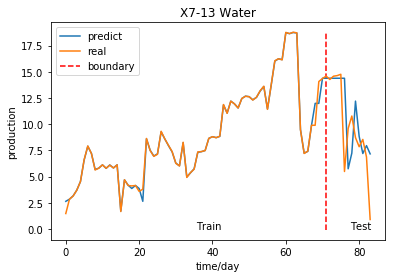

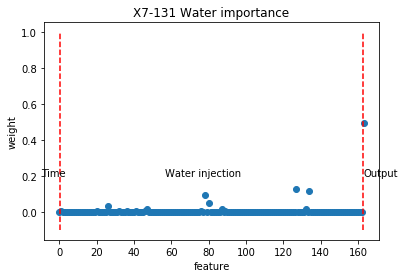

X7-131 Water model.score= -10.358444028617223
X7-131 Water : train_mae= 0.074087 ; train_mse= 0.008657 ; test_mae= 27.447729 ; test_mse= 2226.213894


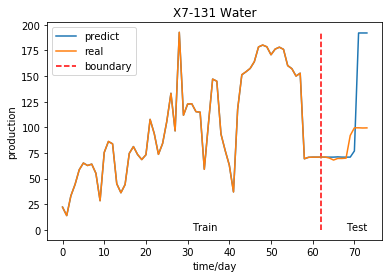

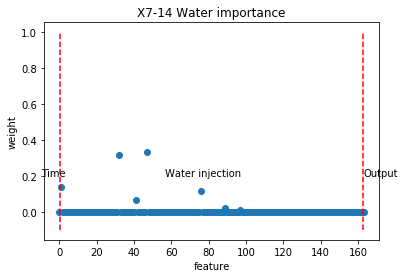

X7-14 Water model.score= -0.47062296033143736
X7-14 Water : train_mae= 0.000937 ; train_mse= 0.000001 ; test_mae= 34.252001 ; test_mse= 1725.334178


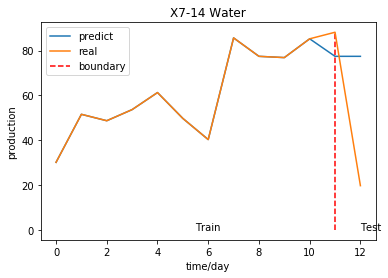

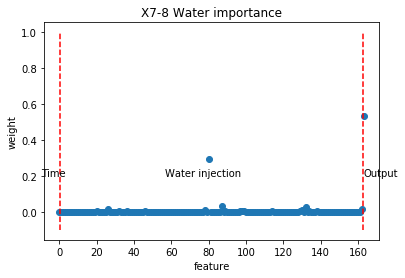

X7-8 Water model.score= -0.7918670341272551
X7-8 Water : train_mae= 0.328667 ; train_mse= 0.543636 ; test_mae= 8.346547 ; test_mse= 144.474096


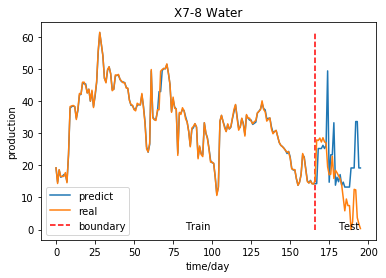

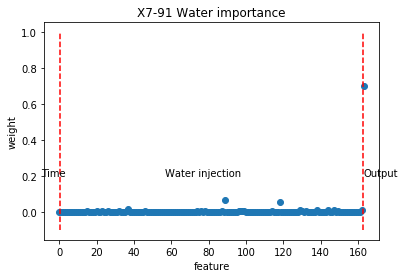

X7-91 Water model.score= 0.7509969881379668
X7-91 Water : train_mae= 1.029556 ; train_mse= 6.574092 ; test_mae= 5.307112 ; test_mse= 86.271989


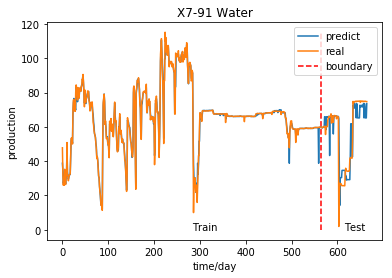

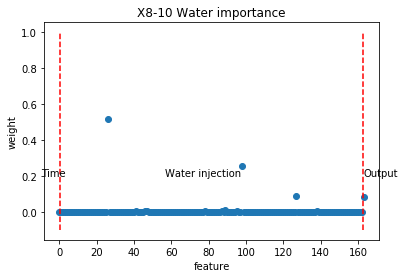

X8-10 Water model.score= -1.711824640173052
X8-10 Water : train_mae= 0.393525 ; train_mse= 3.114190 ; test_mae= 4.172119 ; test_mse= 28.858110


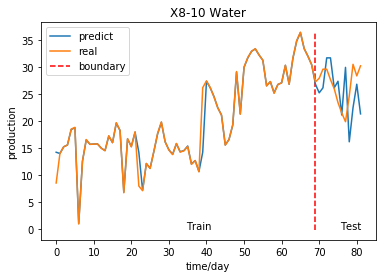

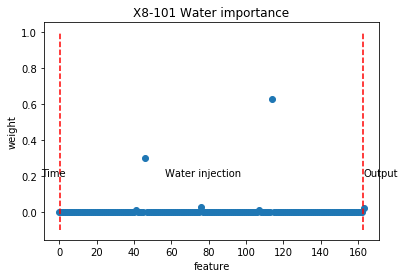

X8-101 Water model.score= -2.63540840546714
X8-101 Water : train_mae= 0.176874 ; train_mse= 0.262598 ; test_mae= 1.025173 ; test_mse= 2.511040


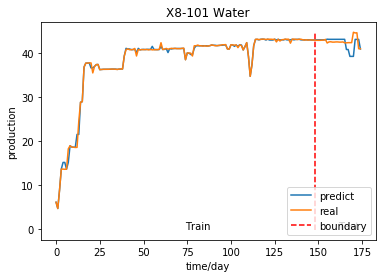

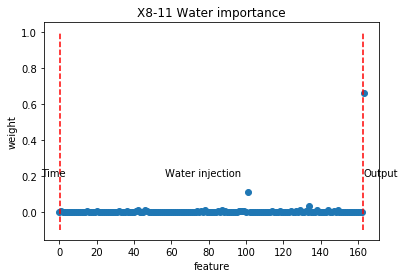

X8-11 Water model.score= -8.295716703715659
X8-11 Water : train_mae= 0.699213 ; train_mse= 2.115494 ; test_mae= 1.624989 ; test_mse= 12.764457


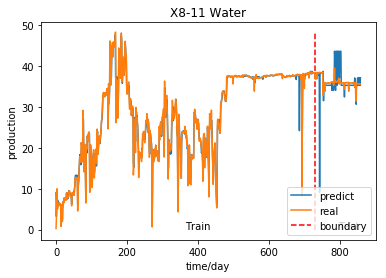

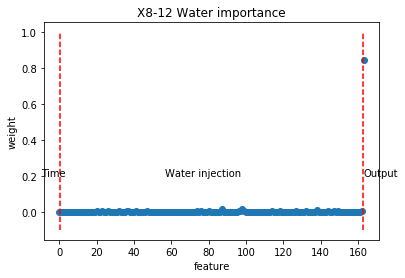

X8-12 Water model.score= 0.0739346454586951
X8-12 Water : train_mae= 2.150030 ; train_mse= 14.343200 ; test_mae= 0.782721 ; test_mse= 0.945088


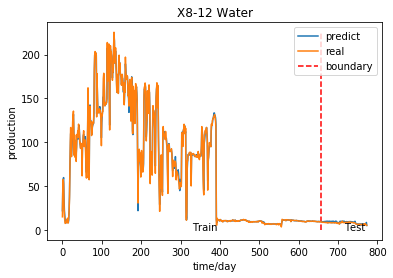

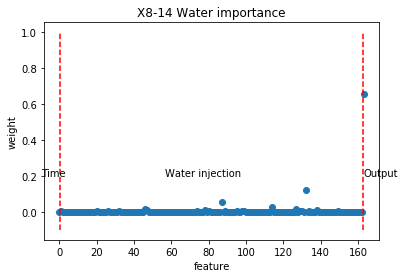

X8-14 Water model.score= 0.5433335003830642
X8-14 Water : train_mae= 0.013656 ; train_mse= 0.001215 ; test_mae= 0.032585 ; test_mse= 0.005673


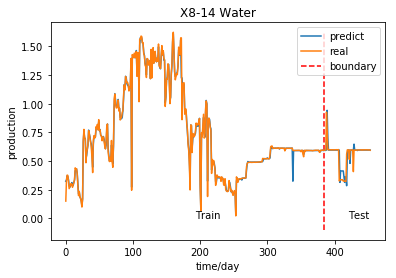

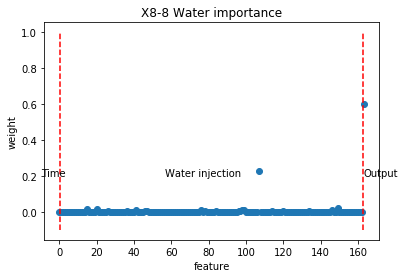

X8-8 Water model.score= -4.902028224135695
X8-8 Water : train_mae= 0.284261 ; train_mse= 0.473967 ; test_mae= 5.622174 ; test_mse= 37.129854


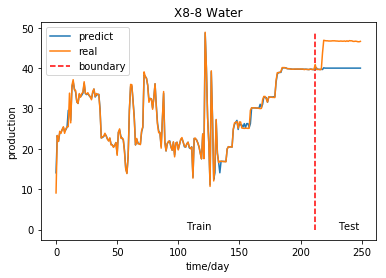

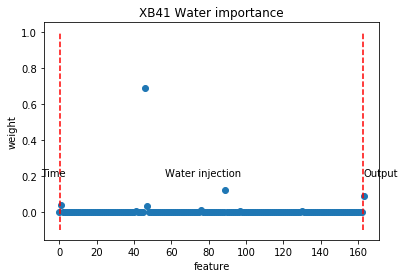

XB41 Water model.score= -0.28771131387562376
XB41 Water : train_mae= 0.097220 ; train_mse= 0.101604 ; test_mae= 12.089061 ; test_mse= 218.130943


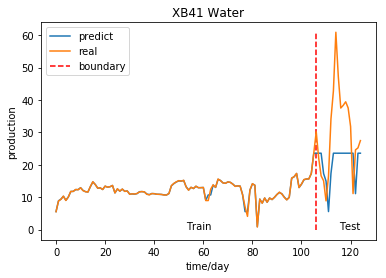

In [5]:
# split into train and test sets
jj = 0
for df_pred in [df0]:
    name = lambda x : "Water" if jj==0 else "Oil"
    for ii in range(1,df0.shape[1]):
        df = pd.concat([df2.iloc[:-1,:].reset_index(drop=True),df_pred.iloc[:-1,[ii]].reset_index(drop=True),df_pred.iloc[1:,[ii]].reset_index(drop=True)],axis=1)
#         print(df)
        df = df.dropna(axis=0,how='any')
        df = df.ix[~(df.iloc[:,-1]==0), :]
        if df.shape[0]<3:
            continue
        n_train_hours = int(0.85 * df.shape[0])
        dataall = np.array(df,dtype=float)
        train = np.array(df.iloc[:n_train_hours, :],dtype=float)
        test = np.array(df.iloc[n_train_hours:, :],dtype=float)
        # split into input and outputs
        train_X, train_y = train[:, :-1], train[:, -1]
        test_X, test_y = test[:, :-1], test[:, -1]

        path = './models100/xgb_'+df_pred.columns[ii]+name(df_pred)+'.pkl'
        my_file = Path(path)
        if my_file.exists():
#             model = joblib.load('./models100/xgb_'+df_pred.columns[ii]+name(df_pred)+'.pkl')
            model = XGBRegressor()
        else:
            model = XGBRegressor()
        model.fit(train_X, train_y)
#         joblib.dump(model, './models100/xgb_'+df_pred.columns[ii]+name(df_pred)+'.pkl')
        importances = model.feature_importances_
        plt.title(df_pred.columns[ii]+' '+name(df_pred)+' importance')
        plt.scatter(np.linspace(0,importances.size-1,importances.size),importances)
        plt.vlines(0.5, -0.1, 1, colors='r', linestyles='--', label='boundary', data=None)
        plt.vlines(df2.shape[1]-0.5, -0.1, 1, colors='r', linestyles='--', label='boundary', data=None)
        plt.text(-10, 0.2, "Time")
        plt.text(df2.shape[1]/2-25, 0.2, "Water injection")
        plt.text(df2.shape[1], 0.2, "Output")
        plt.xlabel('feature')
        plt.ylabel('weight')
        plt.show()
        
        df = pd.concat([df2.iloc[:-1,np.argsort(importances)[:10]].reset_index(drop=True),df_pred.iloc[:-1,[ii]].reset_index(drop=True),df_pred.iloc[1:,[ii]].reset_index(drop=True)],axis=1)
        df = df.dropna(axis=0,how='any')
        df = df.ix[~(df.iloc[:,-1]==0), :]
        dataall = np.array(df,dtype=float)
        train = np.array(df.iloc[:n_train_hours, :],dtype=float)
        test = np.array(df.iloc[n_train_hours:, :],dtype=float)
        train_X, train_y = train[:, :-1], train[:, -1]
        test_X, test_y = test[:, :-1], test[:, -1]
        model = XGBRegressor()
        model.fit(train_X, train_y)
        
        y_pred=model.predict(train_X)
        score11=mean_absolute_error(train_y, y_pred)
        score12=mean_squared_error(train_y, y_pred)
        y_pred=model.predict(test_X)
        score21=mean_absolute_error(test_y, y_pred)
        score22=mean_squared_error(test_y, y_pred)
        print(df_pred.columns[ii],name(df_pred),'model.score=',model.score(test_X,test_y))
        print(df_pred.columns[ii],name(df_pred),": train_mae=",'%.6f'%score11,"; train_mse=",'%.6f'%score12,"; test_mae=",'%.6f'%score21,"; test_mse=",'%.6f'%score22)
        dataout = model.predict(dataall[:,:-1])
        plt.figure(ii)
        plt.title(df_pred.columns[ii]+' '+name(df_pred))
        plt.plot(dataout, label='predict')
        plt.plot(dataall[:,-1], label='real')
        plt.xlabel('time/day')
        plt.ylabel('production')
        plt.text(n_train_hours/2, 0, "Train")
        plt.text(n_train_hours/2+df.shape[0]/2, 0, "Test")
        plt.vlines(n_train_hours, -0.1, np.max(dataall[:,-1]), colors='r', linestyles='--', label='boundary', data=None)
        plt.legend()
        plt.show()
        
    jj = jj+1

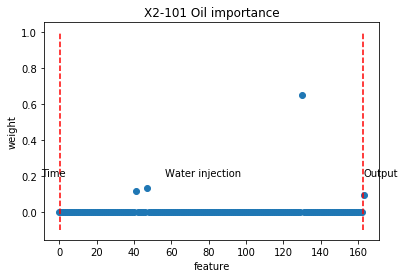

X2-101 Oil model.score= -3609.8350925912687
X2-101 Oil : train_mae= 0.000992 ; train_mse= 0.000001 ; test_mae= 3.517481 ; test_mse= 15.037184


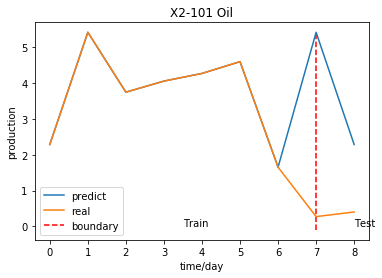

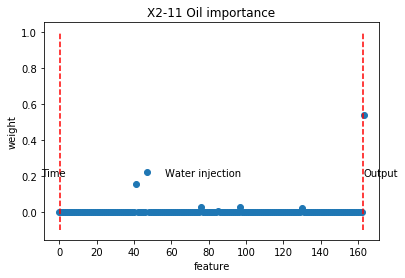

X2-11 Oil model.score= 0.5478487695961682
X2-11 Oil : train_mae= 0.056066 ; train_mse= 0.028933 ; test_mae= 1.378637 ; test_mse= 3.442290


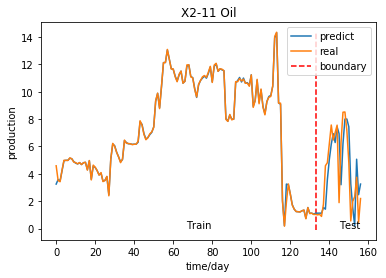

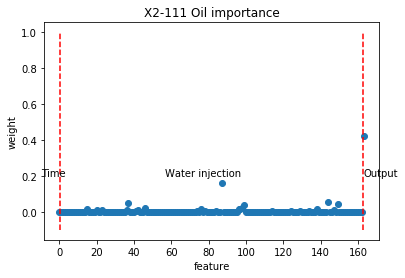

X2-111 Oil model.score= -0.16319659116564345
X2-111 Oil : train_mae= 0.021495 ; train_mse= 0.001547 ; test_mae= 0.017223 ; test_mse= 0.001909


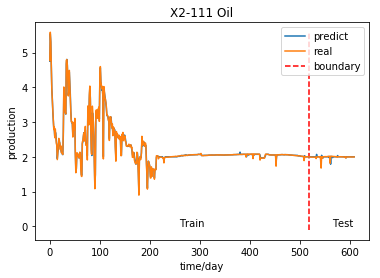

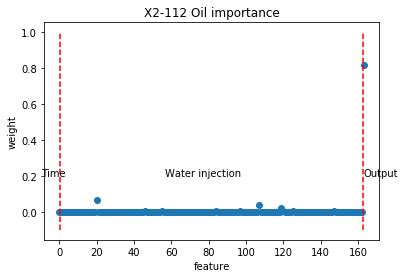

X2-112 Oil model.score= 0.7667400185366426
X2-112 Oil : train_mae= 0.001748 ; train_mse= 0.000070 ; test_mae= 0.005149 ; test_mse= 0.000120


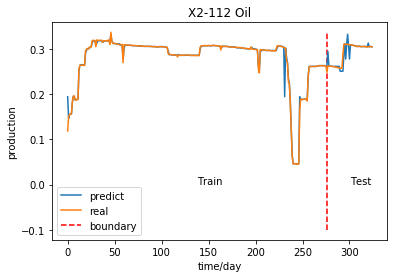

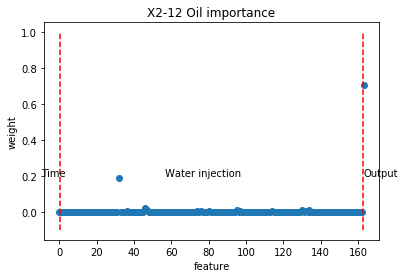

X2-12 Oil model.score= -1.3062901265429865
X2-12 Oil : train_mae= 0.025995 ; train_mse= 0.001110 ; test_mae= 0.295550 ; test_mse= 0.188181


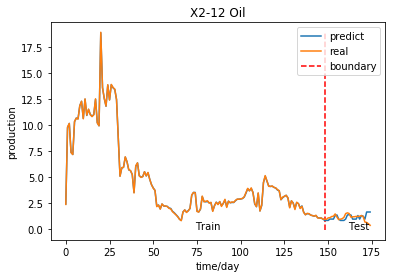

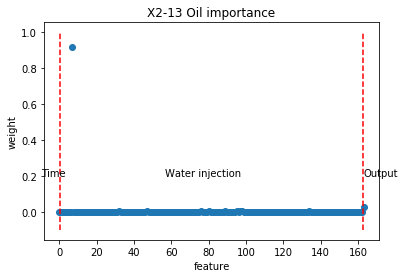

X2-13 Oil model.score= -2.9594905966316687
X2-13 Oil : train_mae= 0.608302 ; train_mse= 17.817904 ; test_mae= 1.348545 ; test_mse= 3.752077


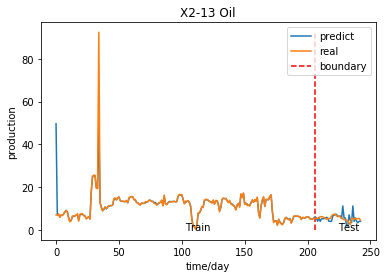

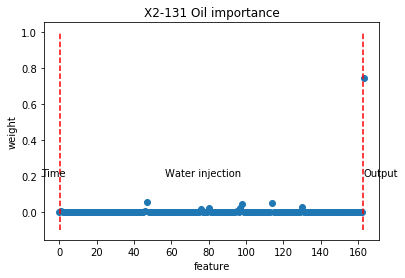

X2-131 Oil model.score= -2.0868189960384016
X2-131 Oil : train_mae= 0.042696 ; train_mse= 0.073653 ; test_mae= 0.033670 ; test_mse= 0.001369


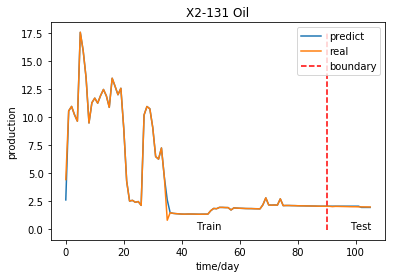

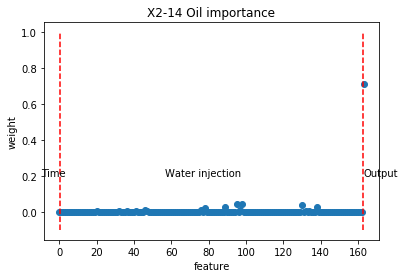

X2-14 Oil model.score= -4.982340884057918
X2-14 Oil : train_mae= 0.017328 ; train_mse= 0.000479 ; test_mae= 0.461143 ; test_mse= 0.436490


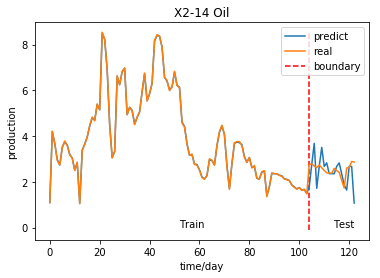

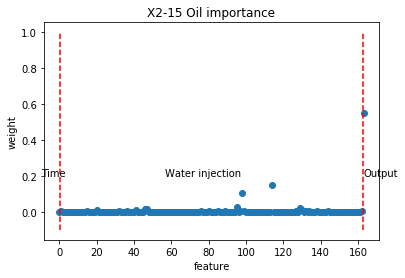

X2-15 Oil model.score= -0.010621564572108166
X2-15 Oil : train_mae= 0.118718 ; train_mse= 0.062470 ; test_mae= 0.557573 ; test_mse= 0.557332


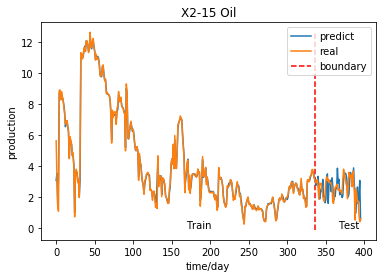

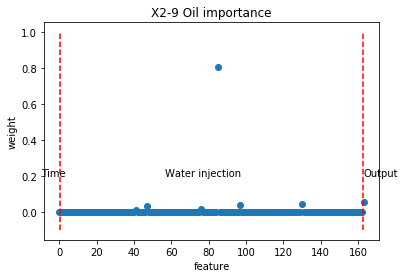

X2-9 Oil model.score= -3.610135418177434
X2-9 Oil : train_mae= 0.075212 ; train_mse= 0.080390 ; test_mae= 1.848806 ; test_mse= 5.250630


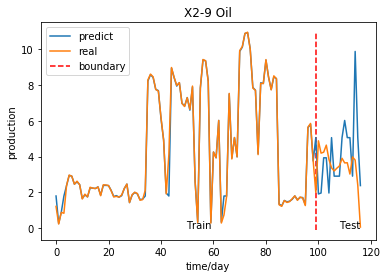

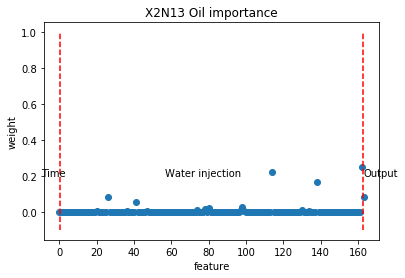

X2N13 Oil model.score= -4.982009904301897
X2N13 Oil : train_mae= 0.002809 ; train_mse= 0.000011 ; test_mae= 1.119120 ; test_mse= 1.482880


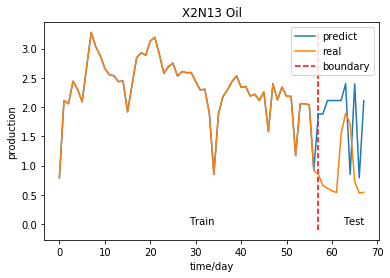

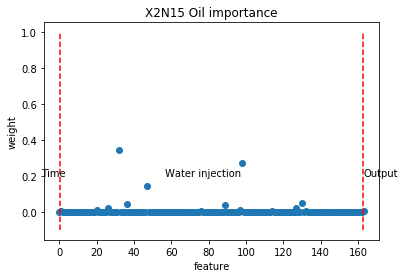

X2N15 Oil model.score= -0.12510328559720207
X2N15 Oil : train_mae= 0.009373 ; train_mse= 0.004687 ; test_mae= 0.039922 ; test_mse= 0.054885


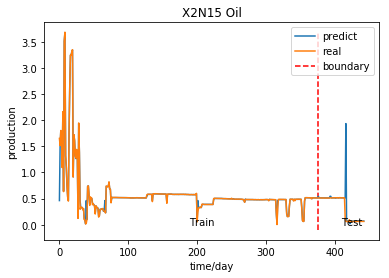

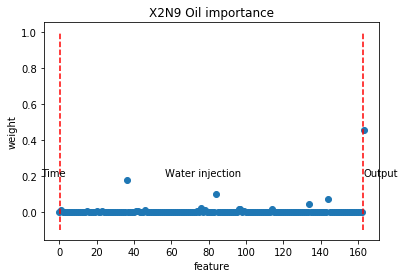

X2N9 Oil model.score= 0.676992973486717
X2N9 Oil : train_mae= 0.003726 ; train_mse= 0.000287 ; test_mae= 0.004914 ; test_mse= 0.000067


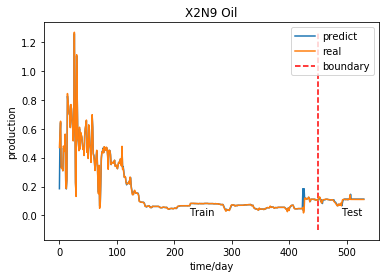

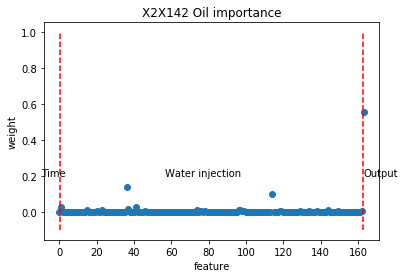

X2X142 Oil model.score= -2.53873719082443
X2X142 Oil : train_mae= 0.004924 ; train_mse= 0.000084 ; test_mae= 0.064704 ; test_mse= 0.064062


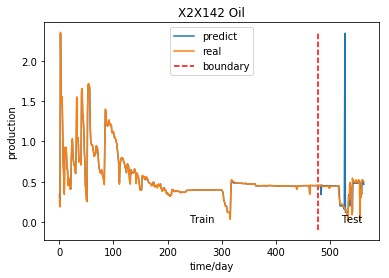

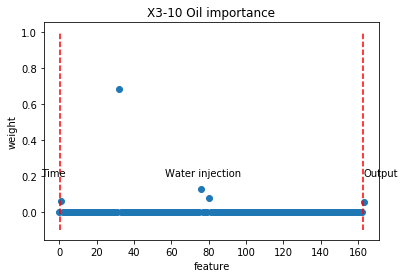

X3-10 Oil model.score= 0.840192936381601
X3-10 Oil : train_mae= 0.001431 ; train_mse= 0.000003 ; test_mae= 0.273852 ; test_mse= 0.076710


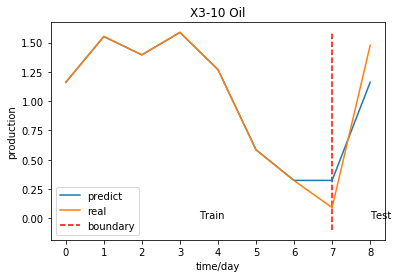

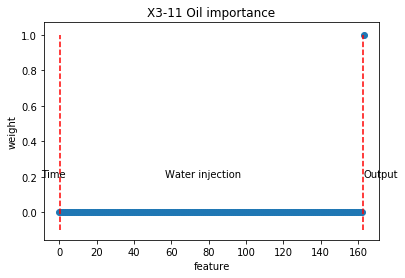

X3-11 Oil model.score= -4.903000925508367
X3-11 Oil : train_mae= 0.001416 ; train_mse= 0.000003 ; test_mae= 0.817429 ; test_mse= 1.013219


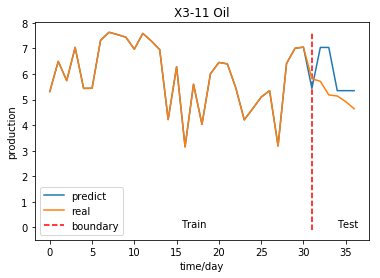

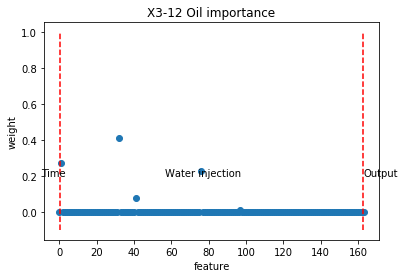

X3-12 Oil model.score= -1790.2373469423958
X3-12 Oil : train_mae= 0.000885 ; train_mse= 0.000001 ; test_mae= 4.003793 ; test_mse= 16.039313


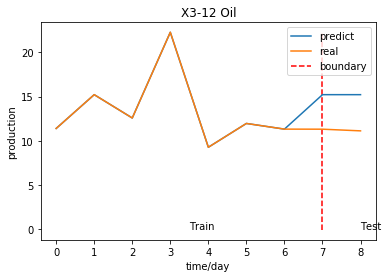

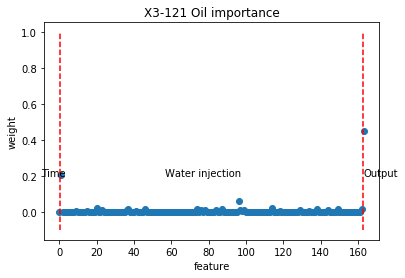

X3-121 Oil model.score= 0.2917978641821529
X3-121 Oil : train_mae= 0.004906 ; train_mse= 0.000073 ; test_mae= 0.026254 ; test_mse= 0.005276


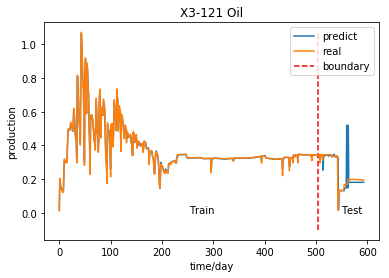

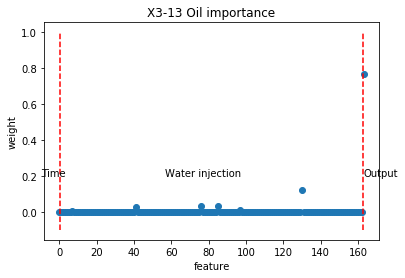

X3-13 Oil model.score= 0.5659973231276358
X3-13 Oil : train_mae= 0.092410 ; train_mse= 0.051900 ; test_mae= 4.342741 ; test_mse= 39.151425


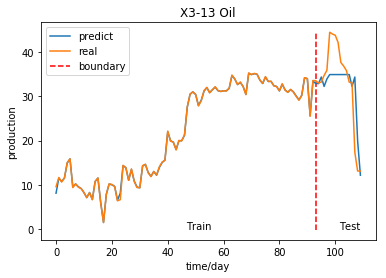

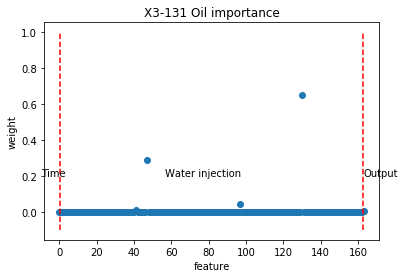

X3-131 Oil model.score= -2809.0760060633443
X3-131 Oil : train_mae= 0.001174 ; train_mse= 0.000002 ; test_mae= 0.456800 ; test_mse= 0.208740


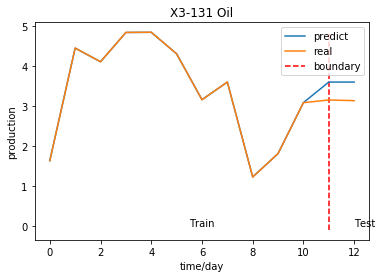

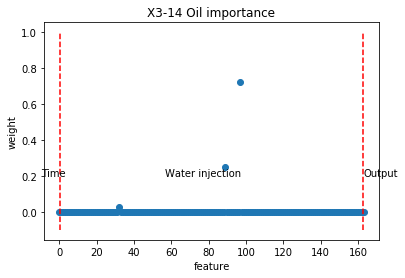

X3-14 Oil model.score= -199.26151291959204
X3-14 Oil : train_mae= 0.001052 ; train_mse= 0.000001 ; test_mae= 4.217781 ; test_mse= 17.789876


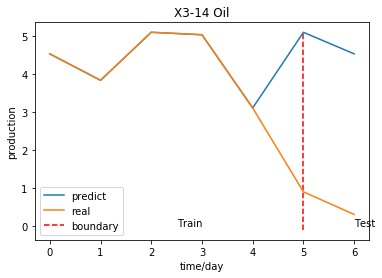

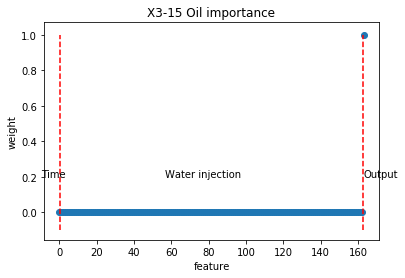

X3-15 Oil model.score= 0.5168559010092835
X3-15 Oil : train_mae= 0.001559 ; train_mse= 0.000003 ; test_mae= 0.675292 ; test_mse= 0.524935


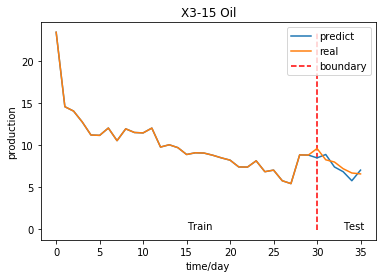

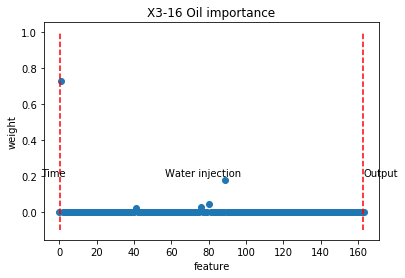

X3-16 Oil model.score= -0.09857220463563121
X3-16 Oil : train_mae= 0.001193 ; train_mse= 0.000002 ; test_mae= 6.997414 ; test_mse= 54.110400


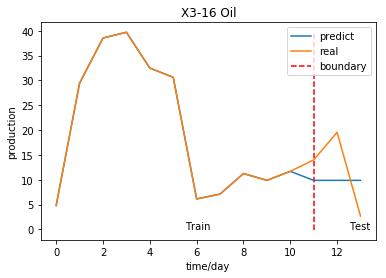

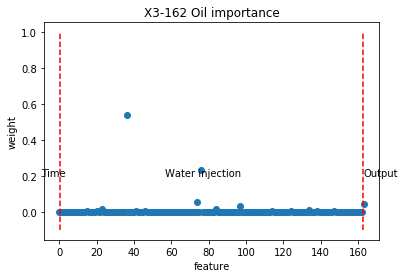

X3-162 Oil model.score= -7813.85230651366
X3-162 Oil : train_mae= 0.007197 ; train_mse= 0.000449 ; test_mae= 0.850381 ; test_mse= 0.917103


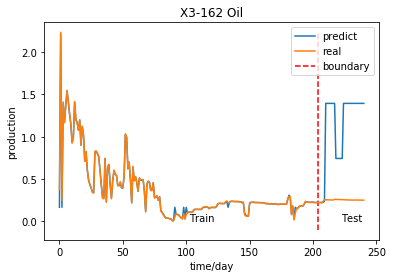

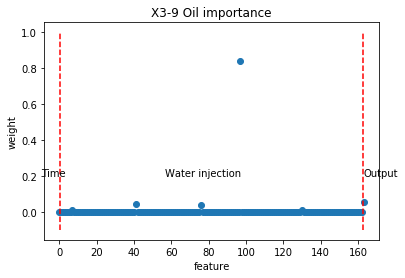

X3-9 Oil model.score= -0.4802200365866549
X3-9 Oil : train_mae= 0.021218 ; train_mse= 0.009787 ; test_mae= 1.520471 ; test_mse= 3.307279


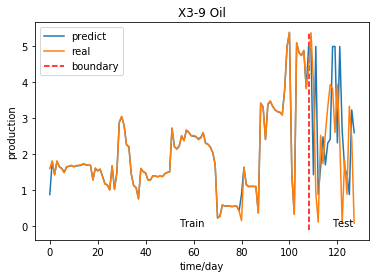

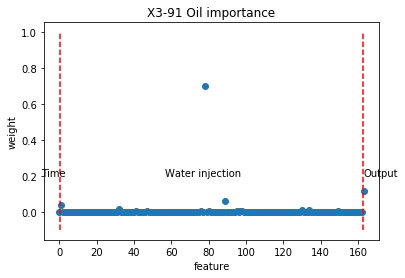

X3-91 Oil model.score= -5.3879546652095645
X3-91 Oil : train_mae= 0.033507 ; train_mse= 0.028288 ; test_mae= 0.015954 ; test_mse= 0.000933


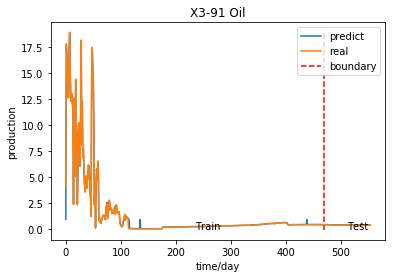

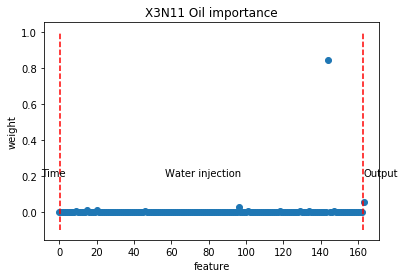

X3N11 Oil model.score= 0.24486365912949012
X3N11 Oil : train_mae= 0.004922 ; train_mse= 0.000193 ; test_mae= 0.017704 ; test_mse= 0.000426


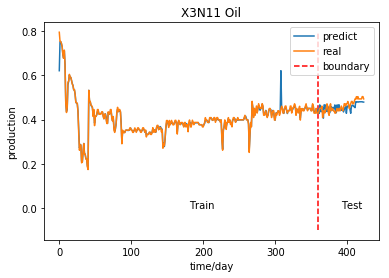

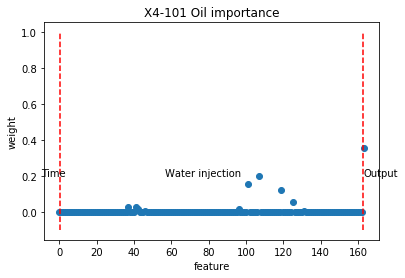

X4-101 Oil model.score= 0.29817829582093347
X4-101 Oil : train_mae= 0.001258 ; train_mse= 0.000002 ; test_mae= 0.016375 ; test_mse= 0.000414


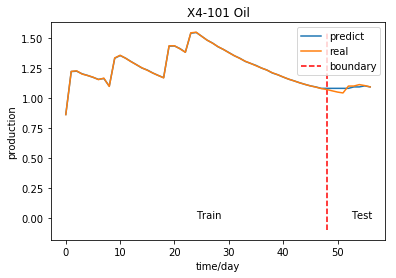

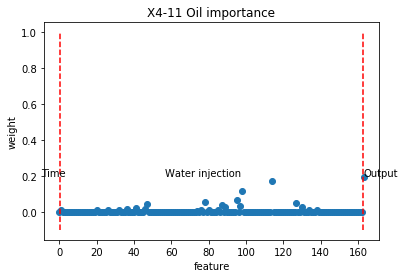

X4-11 Oil model.score= -26.663746880292212
X4-11 Oil : train_mae= 0.150762 ; train_mse= 0.078377 ; test_mae= 2.202962 ; test_mse= 6.912350


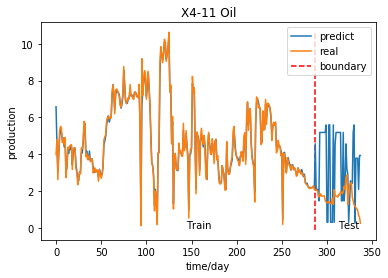

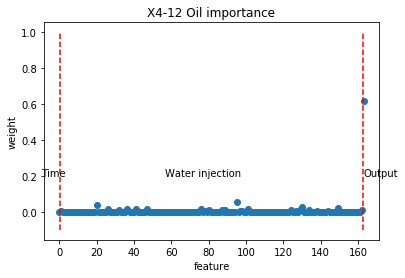

X4-12 Oil model.score= -3.2516735695103023
X4-12 Oil : train_mae= 0.033737 ; train_mse= 0.011952 ; test_mae= 0.018351 ; test_mse= 0.001489


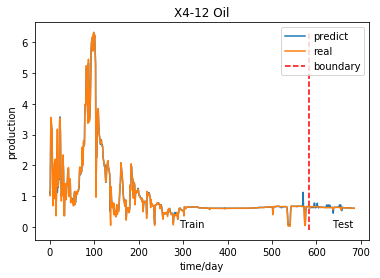

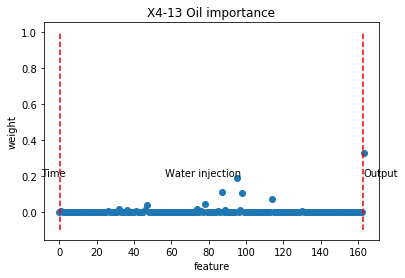

X4-13 Oil model.score= -24.065036636956208
X4-13 Oil : train_mae= 0.137766 ; train_mse= 0.062024 ; test_mae= 0.873378 ; test_mse= 2.827733


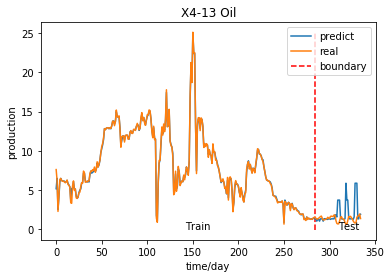

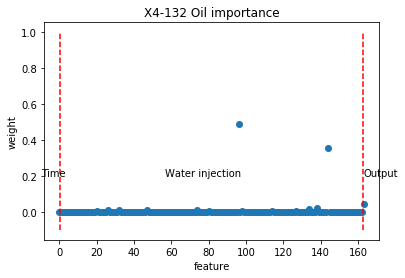

X4-132 Oil model.score= -0.9860564220465016
X4-132 Oil : train_mae= 0.015251 ; train_mse= 0.006096 ; test_mae= 0.000831 ; test_mse= 0.000001


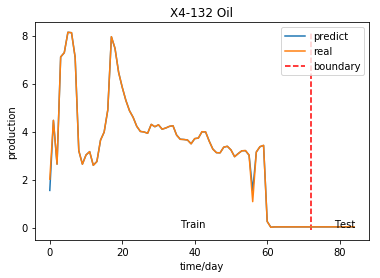

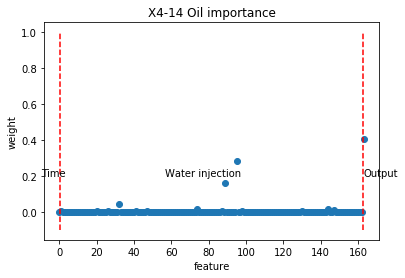

X4-14 Oil model.score= -167.0901152256762
X4-14 Oil : train_mae= 0.008073 ; train_mse= 0.000199 ; test_mae= 0.016971 ; test_mse= 0.004154


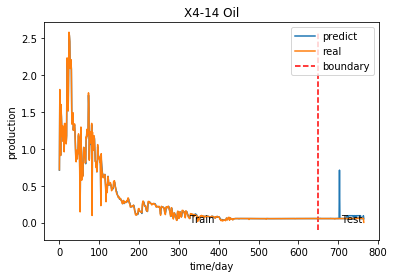

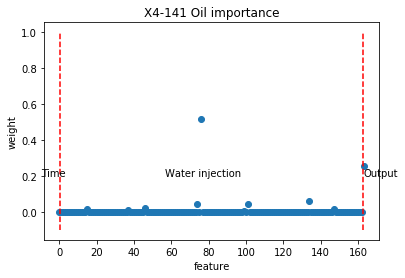

X4-141 Oil model.score= -1.890160110651664
X4-141 Oil : train_mae= 0.002553 ; train_mse= 0.000257 ; test_mae= 0.010638 ; test_mse= 0.000160


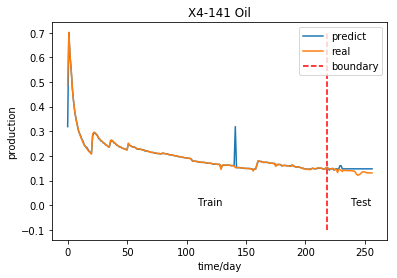

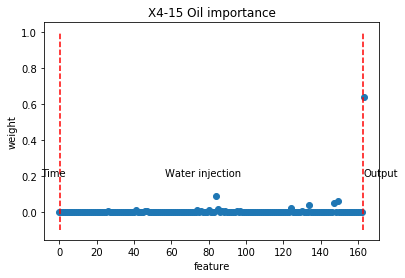

X4-15 Oil model.score= 0.0071622266802535695
X4-15 Oil : train_mae= 0.066452 ; train_mse= 0.015724 ; test_mae= 0.006906 ; test_mse= 0.002281


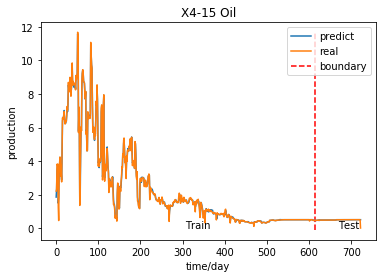

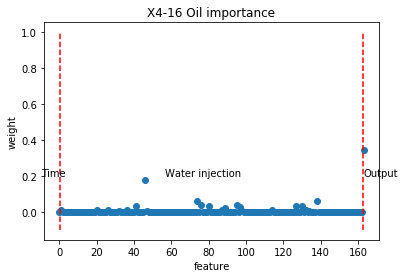

X4-16 Oil model.score= -3.58624881658334
X4-16 Oil : train_mae= 0.212297 ; train_mse= 0.073896 ; test_mae= 1.878734 ; test_mse= 13.649914


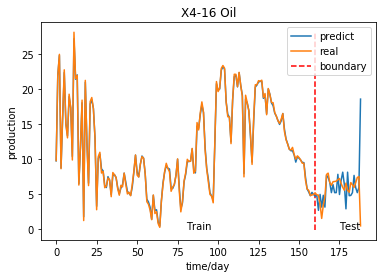

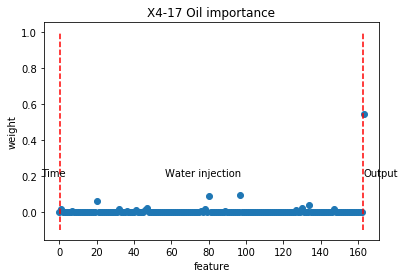

X4-17 Oil model.score= -6.031600711030412
X4-17 Oil : train_mae= 0.092303 ; train_mse= 0.103761 ; test_mae= 0.326377 ; test_mse= 0.142780


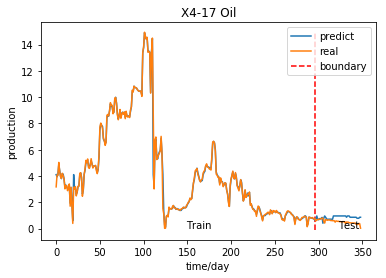

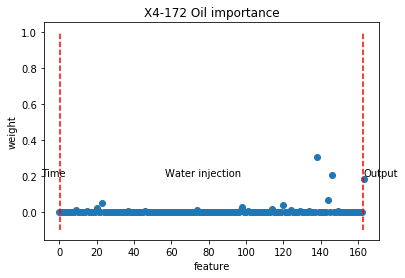

X4-172 Oil model.score= -0.24112603832477708
X4-172 Oil : train_mae= 0.003296 ; train_mse= 0.000634 ; test_mae= 0.019432 ; test_mse= 0.002558


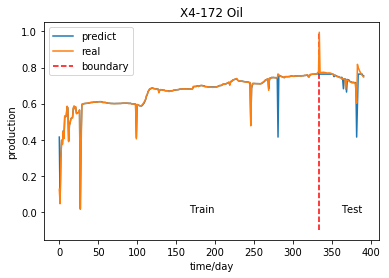

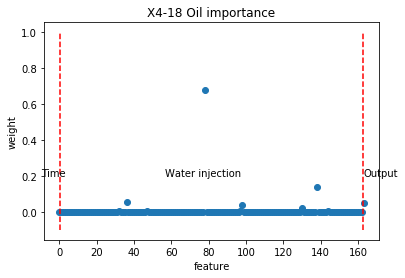

X4-18 Oil model.score= -9504.768053556594
X4-18 Oil : train_mae= 0.001116 ; train_mse= 0.000002 ; test_mae= 8.905641 ; test_mse= 183.655495


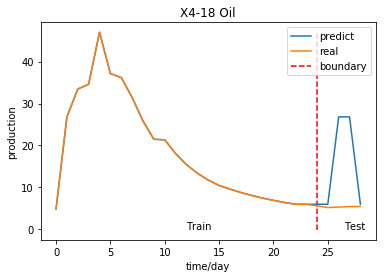

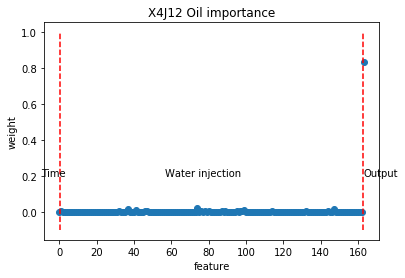

X4J12 Oil model.score= -2.9008501417868295
X4J12 Oil : train_mae= 0.056708 ; train_mse= 0.010243 ; test_mae= 0.019593 ; test_mse= 0.013153


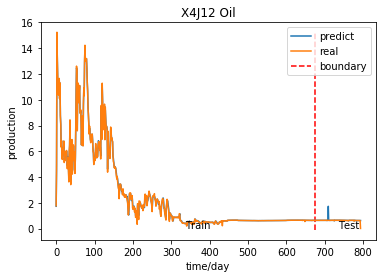

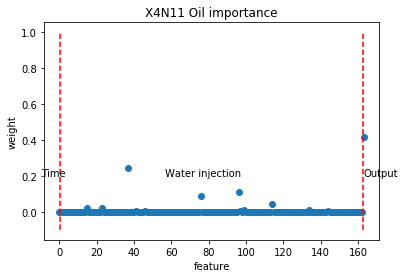

X4N11 Oil model.score= -356.7108136024591
X4N11 Oil : train_mae= 0.016029 ; train_mse= 0.031612 ; test_mae= 0.022527 ; test_mse= 0.029827


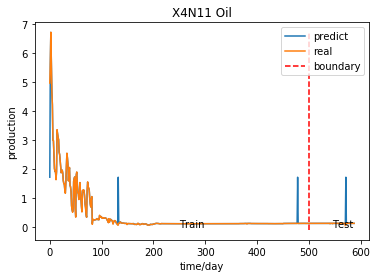

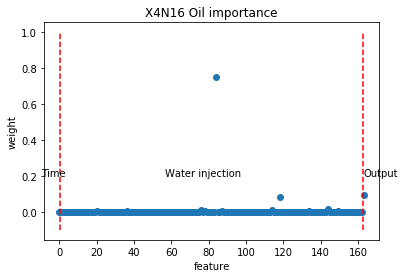

X4N16 Oil model.score= -0.21467547876295212
X4N16 Oil : train_mae= 0.037801 ; train_mse= 0.003718 ; test_mae= 0.007829 ; test_mse= 0.000548


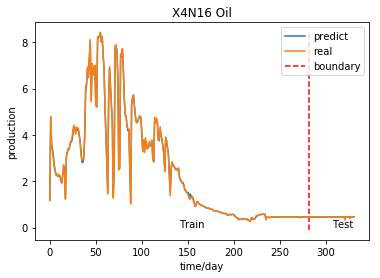

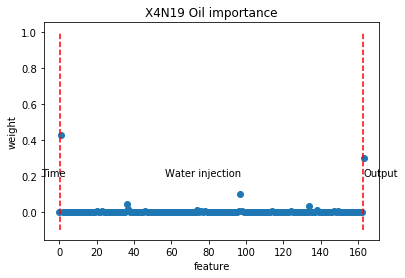

X4N19 Oil model.score= -15.990581474186964
X4N19 Oil : train_mae= 0.017312 ; train_mse= 0.001127 ; test_mae= 0.608067 ; test_mse= 0.589386


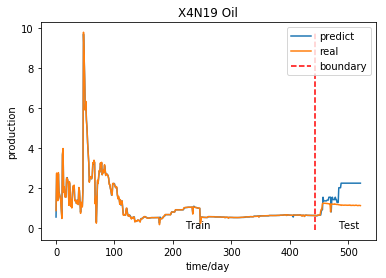

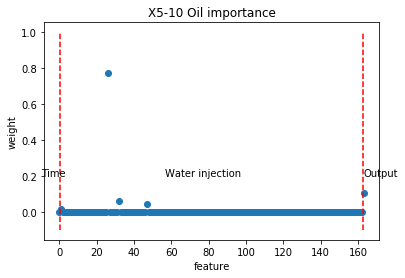

X5-10 Oil model.score= 0.0
X5-10 Oil : train_mae= 0.001294 ; train_mse= 0.000002 ; test_mae= 1.914654 ; test_mse= 3.665898


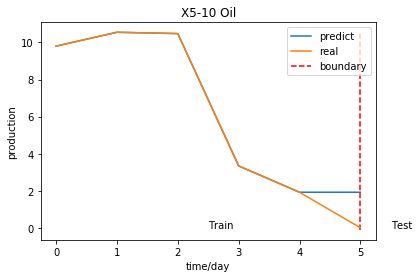

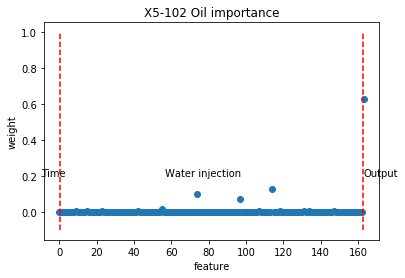

X5-102 Oil model.score= -0.7833670337333606
X5-102 Oil : train_mae= 0.007058 ; train_mse= 0.003559 ; test_mae= 0.044850 ; test_mse= 0.006785


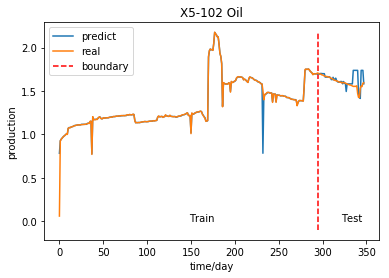

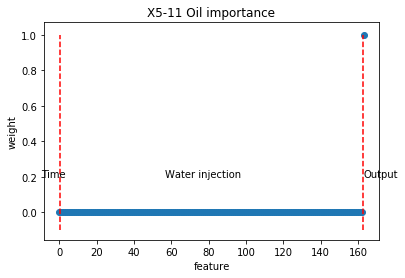

X5-11 Oil model.score= -88.40712250926411
X5-11 Oil : train_mae= 0.001331 ; train_mse= 0.000003 ; test_mae= 4.110371 ; test_mse= 17.086257


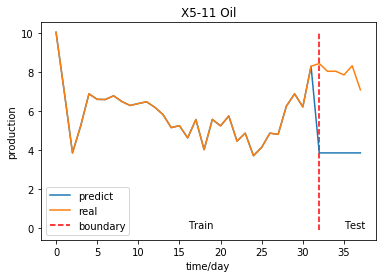

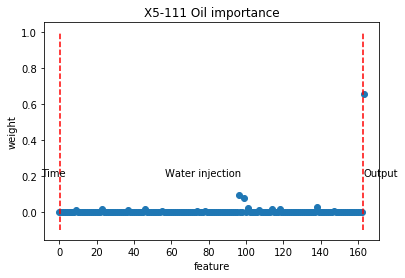

X5-111 Oil model.score= 0.5654415327820416
X5-111 Oil : train_mae= 0.002169 ; train_mse= 0.000052 ; test_mae= 0.084173 ; test_mse= 0.027118


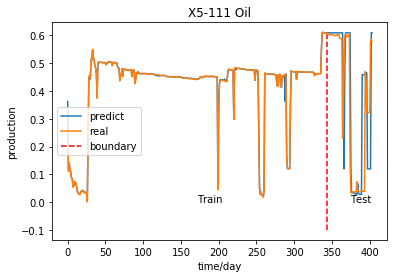

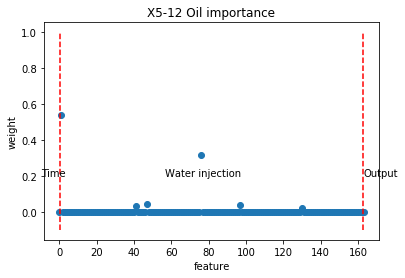

X5-12 Oil model.score= -3.1273040592671446
X5-12 Oil : train_mae= 0.000762 ; train_mse= 0.000001 ; test_mae= 7.439244 ; test_mse= 73.038858


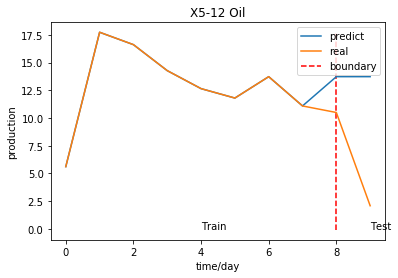

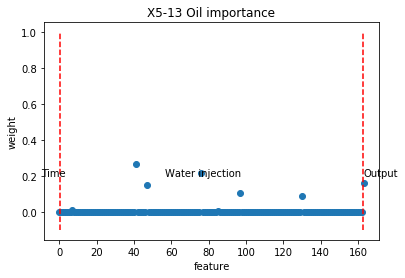

X5-13 Oil model.score= 0.44282476693649225
X5-13 Oil : train_mae= 0.213321 ; train_mse= 0.978592 ; test_mae= 12.928633 ; test_mse= 276.679349


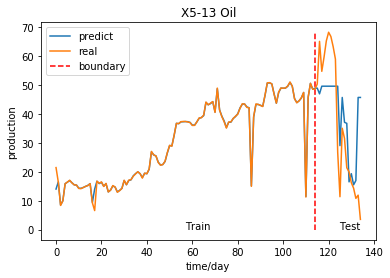

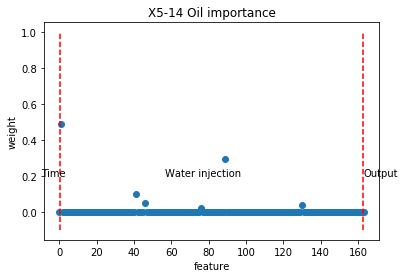

X5-14 Oil model.score= -0.08037215768618688
X5-14 Oil : train_mae= 0.001113 ; train_mse= 0.000002 ; test_mae= 0.770372 ; test_mse= 0.845758


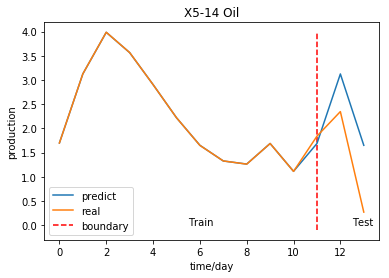

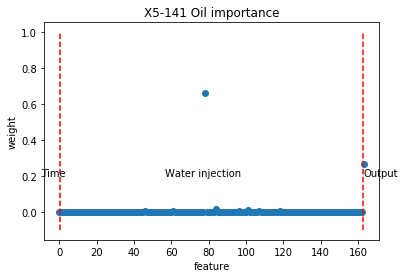

X5-141 Oil model.score= -3.4204904268292227
X5-141 Oil : train_mae= 0.003965 ; train_mse= 0.000030 ; test_mae= 0.176925 ; test_mse= 0.330218


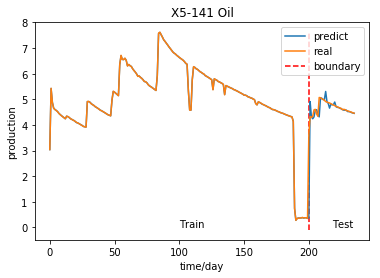

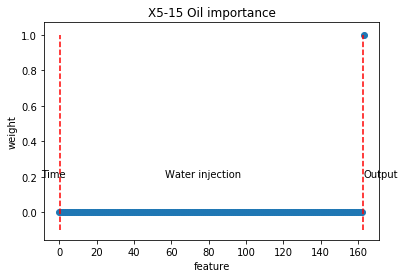

X5-15 Oil model.score= -0.16713043189153787
X5-15 Oil : train_mae= 0.001402 ; train_mse= 0.000003 ; test_mae= 0.328388 ; test_mse= 0.246248


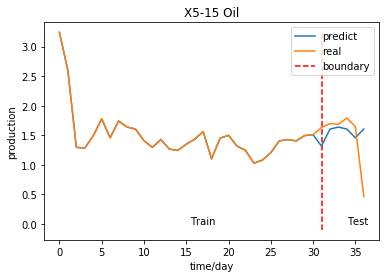

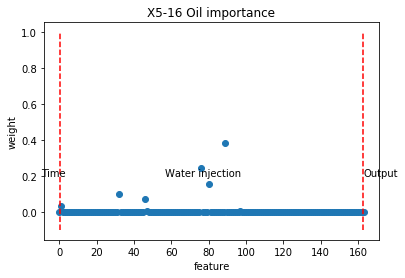

X5-16 Oil model.score= -0.45916106517966027
X5-16 Oil : train_mae= 0.001148 ; train_mse= 0.000001 ; test_mae= 2.222156 ; test_mse= 8.243183


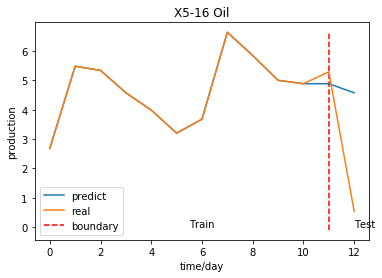

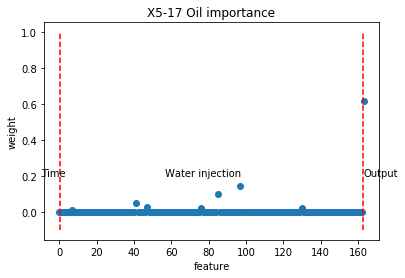

X5-17 Oil model.score= 0.18899133857908235
X5-17 Oil : train_mae= 0.008620 ; train_mse= 0.000114 ; test_mae= 0.592836 ; test_mse= 0.559510


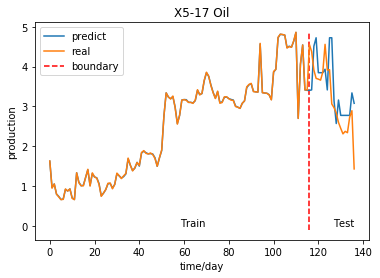

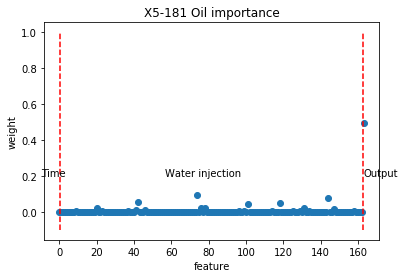

X5-181 Oil model.score= -0.36618362646940056
X5-181 Oil : train_mae= 0.025742 ; train_mse= 0.012547 ; test_mae= 0.058893 ; test_mse= 0.005079


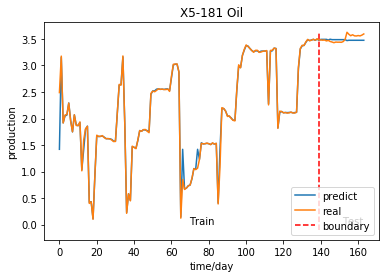

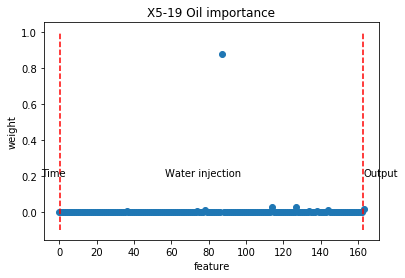

X5-19 Oil model.score= -1.5914982368557746
X5-19 Oil : train_mae= 0.001381 ; train_mse= 0.000062 ; test_mae= 0.003580 ; test_mse= 0.000019


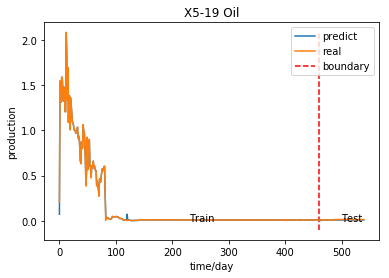

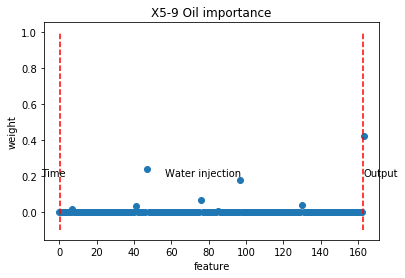

X5-9 Oil model.score= -5.622081809328018
X5-9 Oil : train_mae= 0.032365 ; train_mse= 0.004277 ; test_mae= 0.847221 ; test_mse= 1.290875


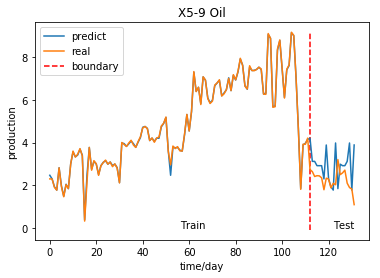

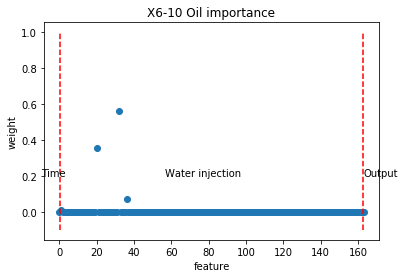

X6-10 Oil model.score= 0.0
X6-10 Oil : train_mae= 0.000444 ; train_mse= 0.000000 ; test_mae= 0.051284 ; test_mse= 0.002630


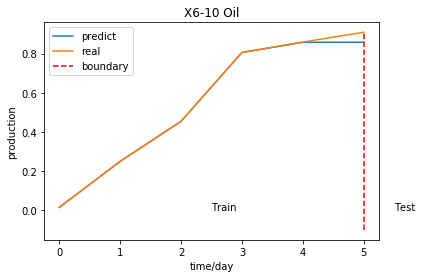

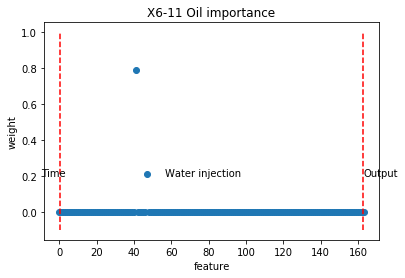

X6-11 Oil model.score= 0.0
X6-11 Oil : train_mae= 0.000688 ; train_mse= 0.000001 ; test_mae= 2.047276 ; test_mse= 4.191339


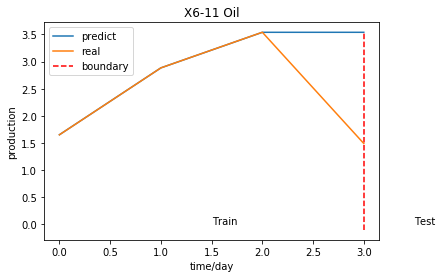

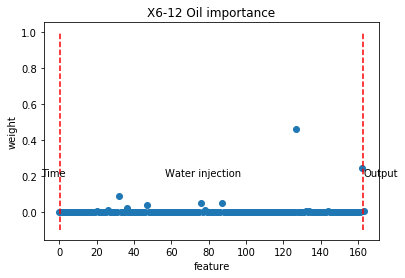

X6-12 Oil model.score= -23.835779517710815
X6-12 Oil : train_mae= 0.001635 ; train_mse= 0.000004 ; test_mae= 0.631841 ; test_mse= 1.914385


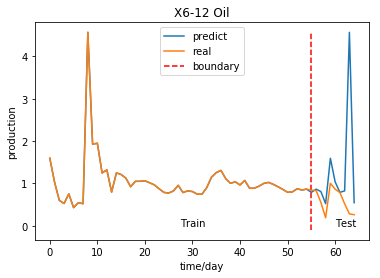

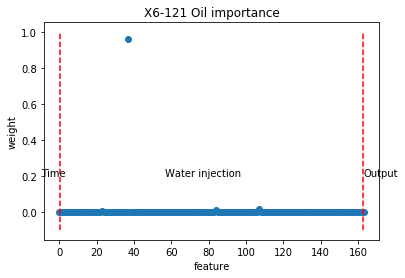

X6-121 Oil model.score= -6.949243370037127
X6-121 Oil : train_mae= 0.022021 ; train_mse= 0.007527 ; test_mae= 0.019156 ; test_mse= 0.000423


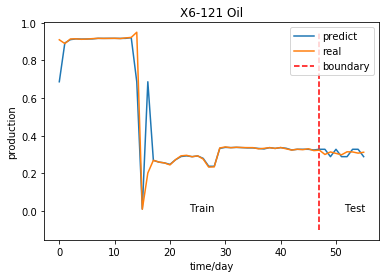

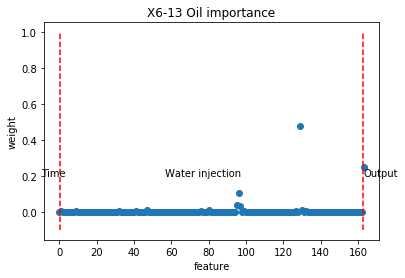

X6-13 Oil model.score= -4.302794792611988
X6-13 Oil : train_mae= 0.069936 ; train_mse= 0.080876 ; test_mae= 0.543387 ; test_mse= 0.657180


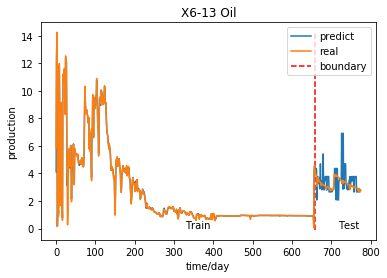

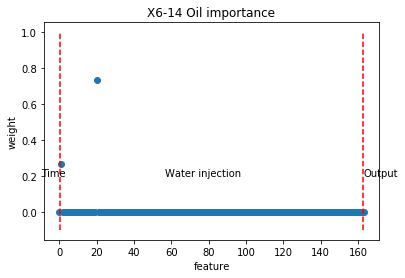

X6-14 Oil model.score= 0.0
X6-14 Oil : train_mae= 0.000916 ; train_mse= 0.000001 ; test_mae= 0.139543 ; test_mse= 0.019472


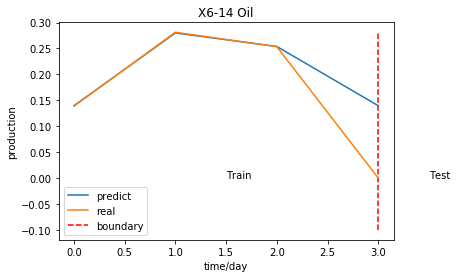

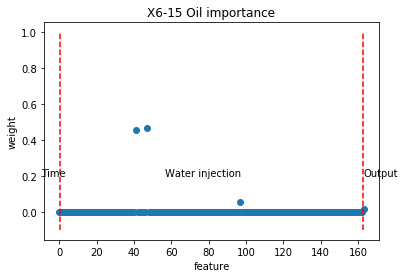

X6-15 Oil model.score= -8.461043872648576
X6-15 Oil : train_mae= 0.001020 ; train_mse= 0.000002 ; test_mae= 1.315920 ; test_mse= 1.732564


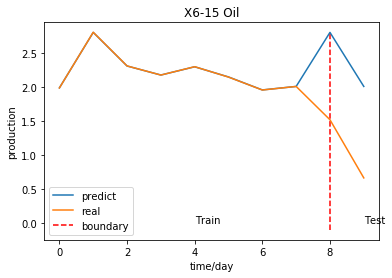

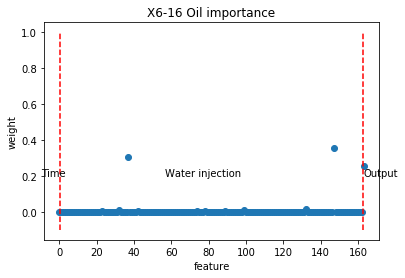

X6-16 Oil model.score= -399.39666605181225
X6-16 Oil : train_mae= 0.029809 ; train_mse= 0.003067 ; test_mae= 0.587668 ; test_mse= 0.648803


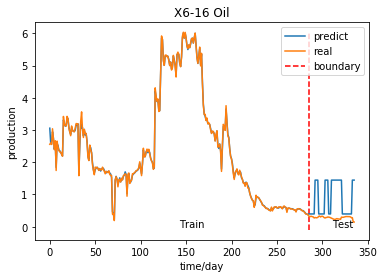

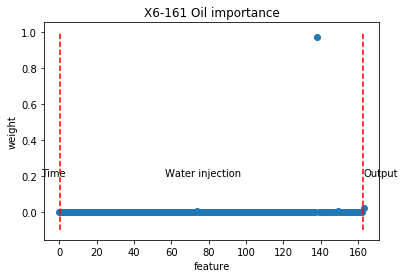

X6-161 Oil model.score= -7.481599101610439
X6-161 Oil : train_mae= 0.019220 ; train_mse= 0.031418 ; test_mae= 0.717750 ; test_mse= 0.613702


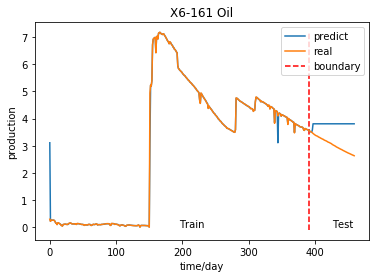

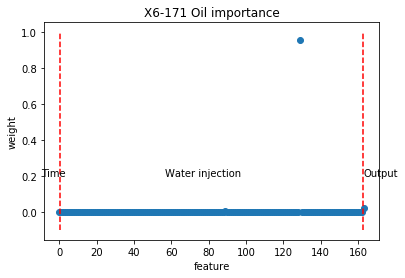

X6-171 Oil model.score= -2.8504613575786837
X6-171 Oil : train_mae= 0.031020 ; train_mse= 0.017213 ; test_mae= 0.006305 ; test_mse= 0.000083


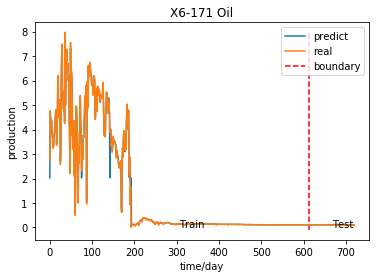

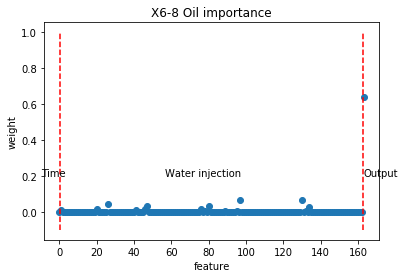

X6-8 Oil model.score= -1.3578887110114657
X6-8 Oil : train_mae= 0.007680 ; train_mse= 0.001394 ; test_mae= 0.048087 ; test_mse= 0.003766


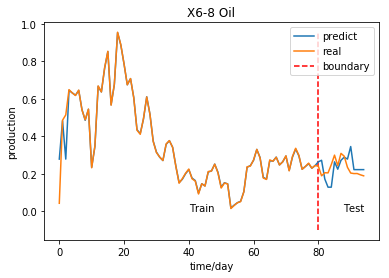

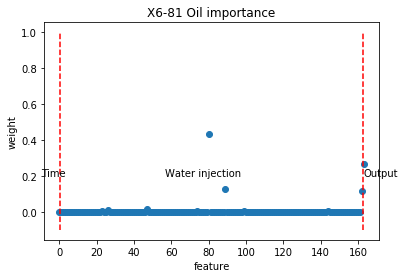

X6-81 Oil model.score= -1.4504432969920131
X6-81 Oil : train_mae= 0.003558 ; train_mse= 0.000038 ; test_mae= 0.004315 ; test_mse= 0.000027


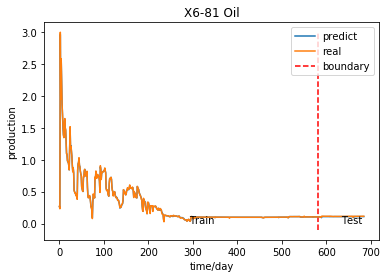

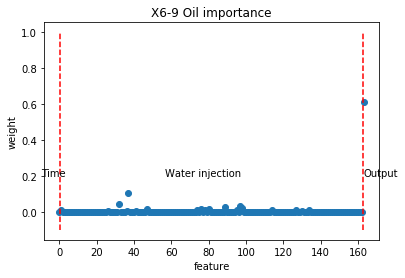

X6-9 Oil model.score= -7.47639313488967
X6-9 Oil : train_mae= 0.048706 ; train_mse= 0.053712 ; test_mae= 0.045702 ; test_mse= 0.047755


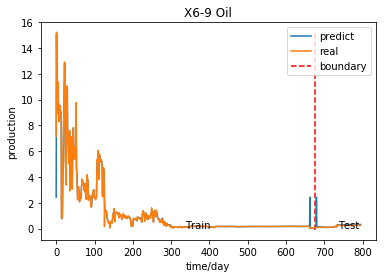

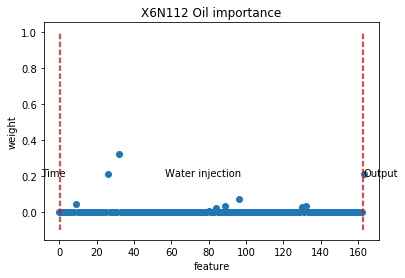

X6N112 Oil model.score= 0.29096747125682443
X6N112 Oil : train_mae= 0.006373 ; train_mse= 0.001861 ; test_mae= 0.000818 ; test_mse= 0.000001


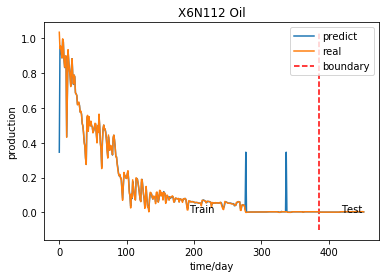

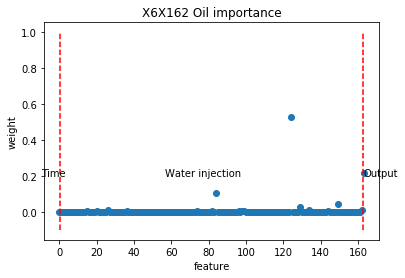

X6X162 Oil model.score= -3.2130106216250067
X6X162 Oil : train_mae= 0.029415 ; train_mse= 0.001687 ; test_mae= 0.029658 ; test_mse= 0.001032


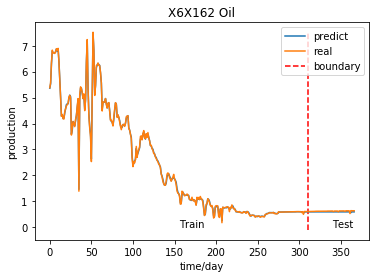

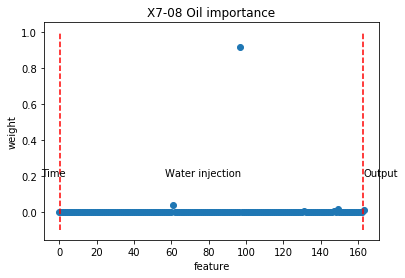

X7-08 Oil model.score= 0.5535119278815914
X7-08 Oil : train_mae= 0.019704 ; train_mse= 0.013638 ; test_mae= 0.367680 ; test_mse= 0.542344


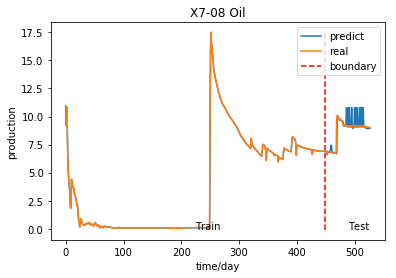

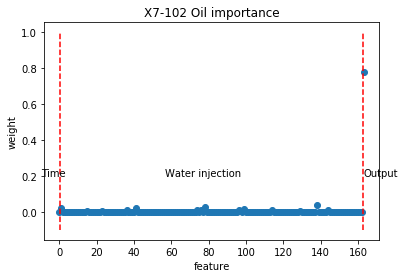

X7-102 Oil model.score= -6.660413286371007
X7-102 Oil : train_mae= 0.002014 ; train_mse= 0.000015 ; test_mae= 0.007046 ; test_mse= 0.000318


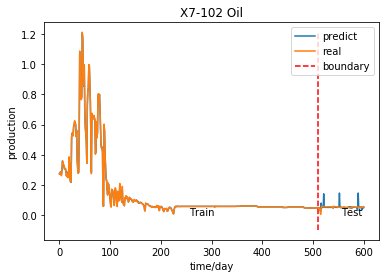

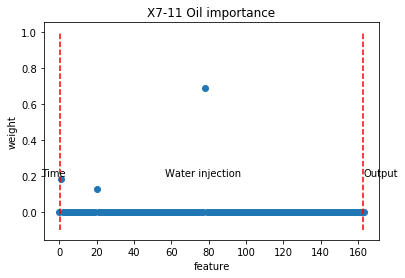

X7-11 Oil model.score= -0.5050484750480704
X7-11 Oil : train_mae= 0.000865 ; train_mse= 0.000001 ; test_mae= 1.899781 ; test_mse= 5.900373


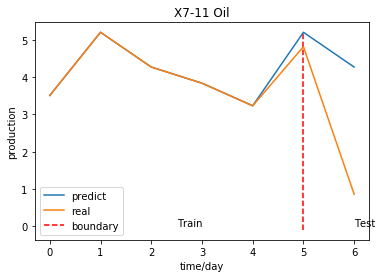

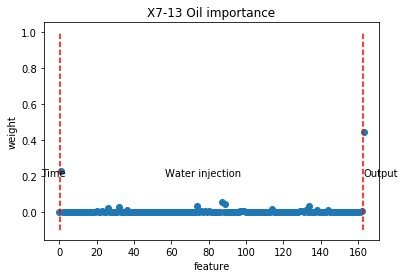

X7-13 Oil model.score= -0.12343099817014846
X7-13 Oil : train_mae= 0.030235 ; train_mse= 0.003397 ; test_mae= 0.086353 ; test_mse= 0.032370


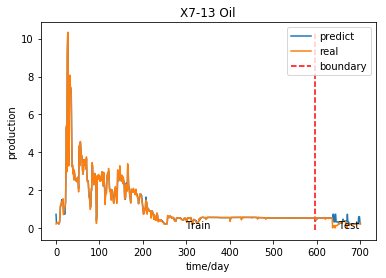

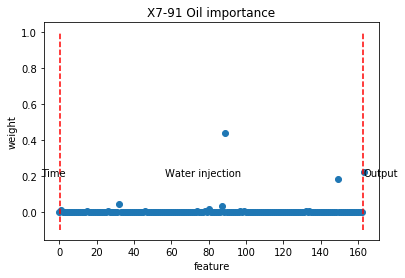

X7-91 Oil model.score= -38.328513522091725
X7-91 Oil : train_mae= 0.083743 ; train_mse= 0.010995 ; test_mae= 6.286589 ; test_mse= 113.596689


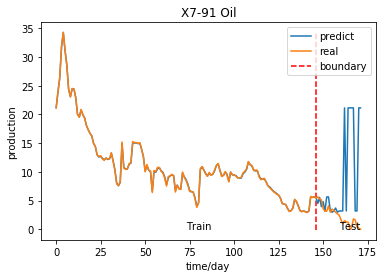

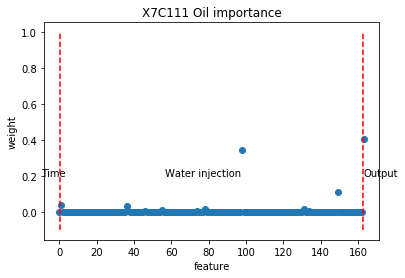

X7C111 Oil model.score= -0.17209572844565058
X7C111 Oil : train_mae= 0.013580 ; train_mse= 0.002936 ; test_mae= 0.370869 ; test_mse= 0.250689


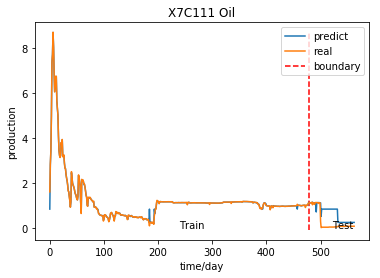

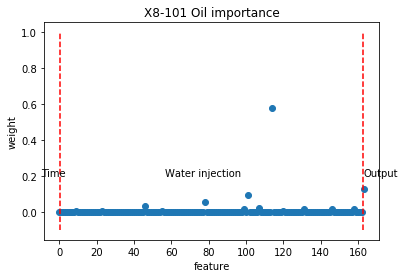

X8-101 Oil model.score= -48.101685944589015
X8-101 Oil : train_mae= 0.001779 ; train_mse= 0.000024 ; test_mae= 0.103617 ; test_mse= 0.011287


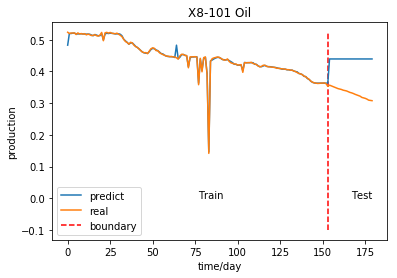

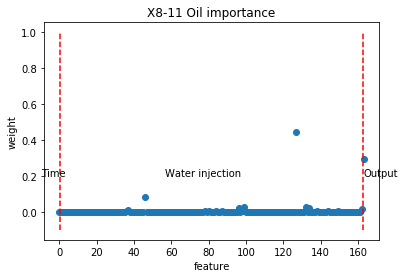

X8-11 Oil model.score= -19.299460648088886
X8-11 Oil : train_mae= 0.040913 ; train_mse= 0.006407 ; test_mae= 0.092806 ; test_mse= 0.058360


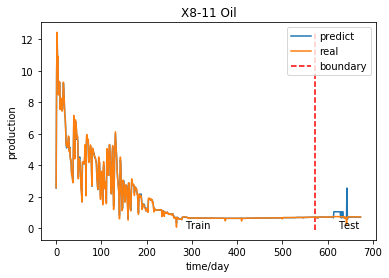

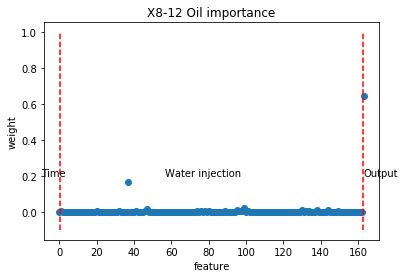

X8-12 Oil model.score= -18.73453396662097
X8-12 Oil : train_mae= 0.430012 ; train_mse= 0.726214 ; test_mae= 0.361294 ; test_mse= 3.414228


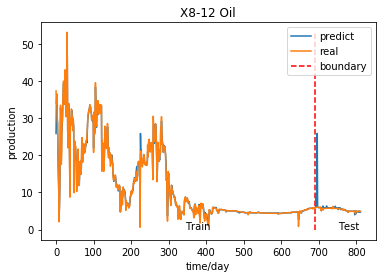

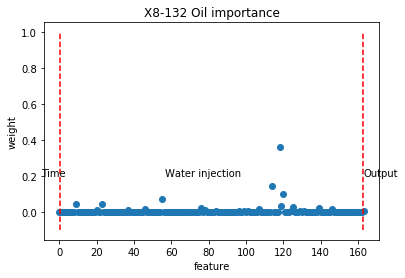

X8-132 Oil model.score= -0.03180625612381238
X8-132 Oil : train_mae= 0.000880 ; train_mse= 0.000003 ; test_mae= 0.210470 ; test_mse= 1.519758


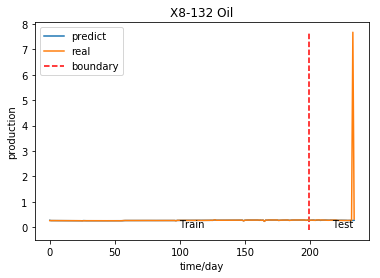

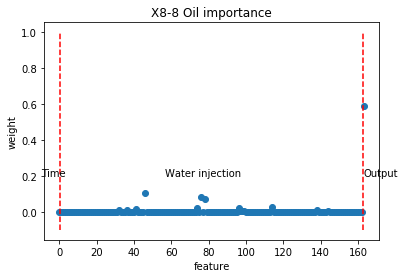

X8-8 Oil model.score= -8545.462265644424
X8-8 Oil : train_mae= 0.032560 ; train_mse= 0.026828 ; test_mae= 0.674798 ; test_mse= 0.660026


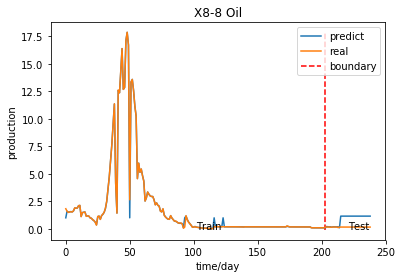

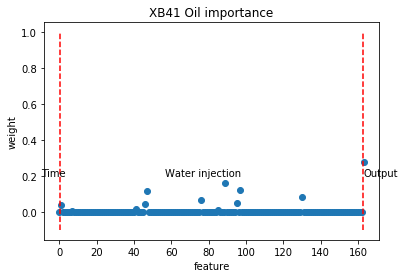

XB41 Oil model.score= -0.07643553906391998
XB41 Oil : train_mae= 0.237911 ; train_mse= 0.387006 ; test_mae= 3.547448 ; test_mse= 22.371975


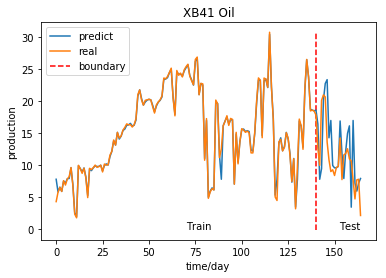

In [6]:
# split into train and test sets
jj = 1
for df_pred in [df1]:
    name = lambda x : "Water" if jj==0 else "Oil"
    for ii in range(1,df0.shape[1]):
        df = pd.concat([df2.iloc[:-1,:].reset_index(drop=True),df_pred.iloc[:-1,[ii]].reset_index(drop=True),df_pred.iloc[1:,[ii]].reset_index(drop=True)],axis=1)
        df = df.dropna(axis=0,how='any')
        df = df.ix[~(df.iloc[:,-1]==0), :]
        if df.shape[0]<3:
            continue
        n_train_hours = int(0.85 * df.shape[0])
        dataall = np.array(df,dtype=float)
        train = np.array(df.iloc[:n_train_hours, :],dtype=float)
        test = np.array(df.iloc[n_train_hours:, :],dtype=float)
        # split into input and outputs
        train_X, train_y = train[:, :-1], train[:, -1]
        test_X, test_y = test[:, :-1], test[:, -1]

        path = './models100/xgb_'+df_pred.columns[ii]+name(df_pred)+'.pkl'
        my_file = Path(path)
        if my_file.exists():
            model = joblib.load('./models4/xgb_'+df_pred.columns[ii]+name(df_pred)+'.pkl')
            model = XGBRegressor()
        else:
            model = XGBRegressor()
        model.fit(train_X, train_y)
        #joblib.dump(model, './models4/xgb_'+df_pred.columns[ii]+name(df_pred)+'.pkl')
        importances = model.feature_importances_
        plt.title(df_pred.columns[ii]+' '+name(df_pred)+' importance')
        plt.scatter(np.linspace(0,importances.size-1,importances.size),importances)
        plt.vlines(0.5, -0.1, 1, colors='r', linestyles='--', label='boundary', data=None)
        plt.vlines(df2.shape[1]-0.5, -0.1, 1, colors='r', linestyles='--', label='boundary', data=None)
        plt.text(-10, 0.2, "Time")
        plt.text(df2.shape[1]/2-25, 0.2, "Water injection")
        plt.text(df2.shape[1], 0.2, "Output")
        plt.xlabel('feature')
        plt.ylabel('weight')
        plt.show()
        
        df = pd.concat([df.iloc[:,np.argsort(importances)[:10]],df.iloc[:,-2:]],axis=1)
#         df = df.dropna(axis=0,how='any')
#         df = df.ix[~(df.iloc[:,-1]==0), :]
        dataall = np.array(df,dtype=float)
        train = np.array(df.iloc[:n_train_hours, :],dtype=float)
        test = np.array(df.iloc[n_train_hours:, :],dtype=float)
        train_X, train_y = train[:, :-1], train[:, -1]
        test_X, test_y = test[:, :-1], test[:, -1]
        model = XGBRegressor()
        model.fit(train_X, train_y)
        
        y_pred=model.predict(train_X)
        score11=mean_absolute_error(train_y, y_pred)
        score12=mean_squared_error(train_y, y_pred)
        y_pred=model.predict(test_X)
        score21=mean_absolute_error(test_y, y_pred)
        score22=mean_squared_error(test_y, y_pred)
        print(df_pred.columns[ii],name(df_pred),'model.score=',model.score(test_X,test_y))
        print(df_pred.columns[ii],name(df_pred),": train_mae=",'%.6f'%score11,"; train_mse=",'%.6f'%score12,"; test_mae=",'%.6f'%score21,"; test_mse=",'%.6f'%score22)
        dataout = model.predict(dataall[:,:-1])
        plt.figure(ii)
        plt.title(df_pred.columns[ii]+' '+name(df_pred))
        plt.plot(dataout, label='predict')
        plt.plot(dataall[:,-1], label='real')
        plt.xlabel('time/day')
        plt.ylabel('production')
        plt.text(n_train_hours/2, 0, "Train")
        plt.text(n_train_hours/2+df.shape[0]/2, 0, "Test")
        plt.vlines(n_train_hours, -0.1, np.max(dataall[:,-1]), colors='r', linestyles='--', label='boundary', data=None)
        plt.legend()
        plt.show()
        
    jj = jj+1

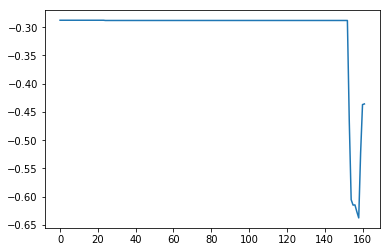

In [57]:
score=[]
for jj in range(0,df2.shape[1]-1):
    df = pd.concat([df2.iloc[:-1,np.argsort(importances)[:jj]].reset_index(drop=True),df_pred.iloc[:-1,[ii]].reset_index(drop=True),df_pred.iloc[1:,[ii]].reset_index(drop=True)],axis=1)
    df = df.dropna(axis=0,how='any')
    df = df.ix[~(df.iloc[:,-1]==0), :]
    dataall = np.array(df,dtype=float)
    train = np.array(df.iloc[:n_train_hours, :],dtype=float)
    test = np.array(df.iloc[n_train_hours:, :],dtype=float)
    train_X, train_y = train[:, :-1], train[:, -1]
    test_X, test_y = test[:, :-1], test[:, -1]
    model = XGBRegressor()
    model.fit(train_X, train_y)
    score.append(model.score(test_X,test_y))
score = np.array(score,dtype=float)
plt.plot(score)


In [117]:
df0 = pd.read_excel(Path,header=0,sheet_name = 0) #产液
df1 = pd.read_excel(Path,header=0,sheet_name = 1) #产油
df2 = pd.read_excel(Path,header=0,sheet_name = 2) #注水
df3 = pd.read_excel(Path,header=0,sheet_name = 3) #位置
df0 = df0.dropna(axis=0,how='any')
df1 = df1.dropna(axis=0,how='any')
df2 = df2.dropna(axis=0,how='any')
# df0 = df0.reset_index()
# df1 = df1.reset_index()
# df2 = df2.reset_index()

In [133]:
df00 = pd.DataFrame(columns = df0.columns,index=range(0,df0.index[-1]))
df00 = df00.combine_first(df0)
df00 = df00.interpolate()
df11 = pd.DataFrame(columns = df1.columns,index=range(0,df1.index[-1]))
df11 = df11.combine_first(df1)
df11 = df11.interpolate()
df22 = pd.DataFrame(columns = df2.columns,index=range(0,df2.index[-1]))
df22 = df22.combine_first(df2)
df22 = df22.interpolate()
# df00.index = range(0,df0.index[-1])

In [150]:
df0 = df00
df1 = df11
df2 = df22
from sklearn.preprocessing import StandardScaler
df0 = pd.concat([df0,df2.iloc[:,1]],axis=1)

In [151]:
df0_addnoise = []
for i in range(0,df0.shape[1]):
    df0_addnoise_temp = df0.iloc[:,i].values + np.random.normal(0,0.005,[1,df0.shape[0]])
    df0_addnoise.append(df0_addnoise_temp)
df0_addnoise = np.array(df0_addnoise,dtype = float)
df0_addnoise = df0_addnoise.reshape([df0_addnoise.shape[0],df0_addnoise.shape[2]])
scaler0 = StandardScaler()
trans_data = scaler0.fit_transform(df0_addnoise.T)
# scaler.fit(df0_addnoise.T)  
# trans_data = scaler.transform(df0_addnoise.T)
df0_addnoise = trans_data.T

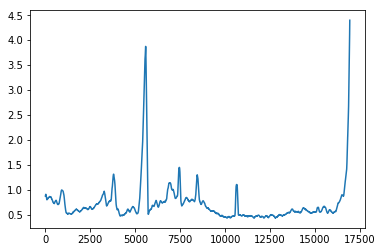

In [143]:
window_size = 120
t0 = []
for win in range(0,df0.shape[0]-window_size):
    df0_win = df0_addnoise[:,win:win+window_size]
    M0 = np.matmul(df0_win,df0_win.T)/df0_win.shape[0]
    E0,V0 = np.linalg.eig(M0)
    t0.append(np.mean(E0))
plt.plot(t0)

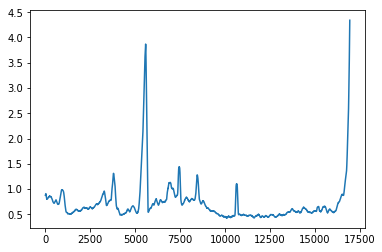

In [152]:
window_size = 120
t0 = []
for win in range(0,df0.shape[0]-window_size):
    df0_win = df0_addnoise[:,win:win+window_size]
    M0 = np.matmul(df0_win,df0_win.T)/df0_win.shape[0]
    E0,V0 = np.linalg.eig(M0)
    t0.append(np.mean(E0))
plt.plot(t0)

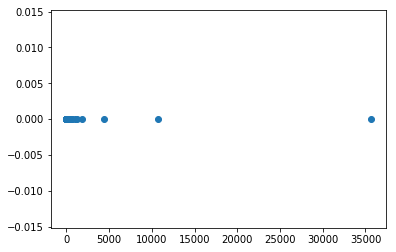

In [92]:
M0 = np.matmul(df0_addnoise,df0_addnoise.T)/df0_addnoise.shape[0]
E0,V0 = np.linalg.eig(M0)
t0 = np.mean(E0)
plt.scatter(np.real(E0),np.imag(E0))

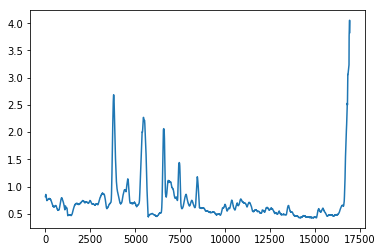

In [146]:
df1_addnoise = []
for i in range(0,df1.shape[1]):
    df1_addnoise_temp = df11.iloc[:,i].values + np.random.normal(0,0.005,[1,df11.shape[0]])
    df1_addnoise.append(df1_addnoise_temp)
df1_addnoise = np.array(df1_addnoise,dtype = float)
df1_addnoise = df1_addnoise.reshape([df1_addnoise.shape[0],df1_addnoise.shape[2]])
scaler1 = StandardScaler()
trans_data = scaler1.fit_transform(df1_addnoise.T)
df1_addnoise = trans_data.T
window_size = 120
t1 = []
for win in range(0,df11.shape[0]-window_size):
    df1_win = df1_addnoise[:,win:win+window_size]
    M1 = np.matmul(df1_win,df1_win.T)/df1_win.shape[0]
    E1,V1 = np.linalg.eig(M1)
    t1.append(np.mean(E1))
plt.plot(t1)

In [35]:
df2_addnoise = []
for i in range(0,df2.shape[1]):
    df2_addnoise_temp = df22.iloc[:,i].values + np.random.normal(0,0.005,[1,df22.shape[0]])
    df2_addnoise.append(df2_addnoise_temp)
df2_addnoise = np.array(df2_addnoise,dtype = float)
df2_addnoise = df2_addnoise.reshape([df2_addnoise.shape[0],df2_addnoise.shape[2]])
scaler2 = StandardScaler()
trans_data = scaler2.fit_transform(df2_addnoise.T)
df2_addnoise = trans_data.T
window_size = 120
t2 = []
for win in range(0,df22.shape[0]-window_size):
    df2_win = df2_addnoise[:,win:win+window_size]
    M2 = np.matmul(df2_win,df2_win.T)/df2_win.shape[0]
    E2,V2 = np.linalg.eig(M2)
    t2.append(np.mean(E2))
plt.plot(t2)

(945, 945)

<AxesSubplot:>

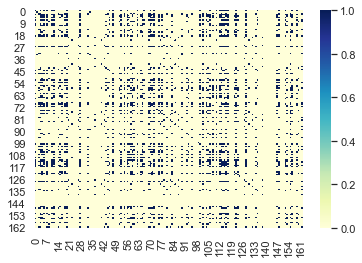

In [25]:
import seaborn as sns
df0 = df0.dropna(axis=0,how='any')
pccs = np.corrcoef(df0.transpose())
np.where(np.abs(pccs)>0.2,1,0)
sns.set()
sns.heatmap(np.where(np.abs(pccs)>0.3,1,0), fmt="d",cmap='YlGnBu')

In [20]:
# df.ix[~(df.iloc[:,:]==0)]
df = df0.iloc[:,[0,2]]
df[~(df.iloc[:,:]==0)].dropna(axis=0,how='any')

,X2-10,X2-11
3772,2.919041,1.977351
3802,7.773016,1.923068
3833,4.834706,1.830059
3864,1.172942,1.931343
3894,9.105363,2.003499
3925,8.425351,1.066790
3955,2.017964,2.292787
3986,3.007327,1.712556
4017,0.756036,1.852566
4046,0.287630,1.797622


In [42]:
df = df0.iloc[:,np.where(np.where(np.abs(pccs)>0.6,1,0)[0]==1)[0]]
df = df[~(df.iloc[:,:]==0)].dropna(axis=0,how='any')
df.shape

(65, 6)

In [60]:
df_all = pd.concat([df2.loc[np.array(df.index),:].reset_index(drop=True),df.reset_index(drop=True)],axis=1)
df22 = df2.loc[np.array(df.index),:]
df22[~(df22.iloc[:,:]==0)].dropna(axis=0,how='all')
# df2.ix[~(df2.iloc[:,-1]==0), :]

,X2-10,X2-101,X2-11,X2-111,X2-112,X2-12,X2-121,X2-13,X2-131,X2-132,...,X8-101,X8-102,X8-11,X8-12,X8-122,X8-132,X8-14,X8-8,X8-9,XB41
3802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3925,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4138,NaN,17.451774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
np.array(df.index)

array([3802, 3833, 3864, 3894, 3925, 3955, 3986, 4017, 4046, 4138, 4168,
       4199, 5113, 5141, 5172, 5202, 5233, 5263, 5294, 5325, 5355, 5386,
       5416, 5447, 5478, 5507, 5538, 5568, 5599, 6178, 6209, 6237, 6268,
       6298, 6329, 6359, 6390, 6421, 6451, 6482, 6512, 6543, 6574, 6602,
       6633, 6663, 6694, 6724, 6755, 6786, 6816, 6847, 6877, 6908, 6939,
       6968, 6999, 7029, 7060, 7274, 7305, 7333, 7364, 7394, 7425],
      dtype=int64)